<a href="https://colab.research.google.com/github/luiscaaa/TDG_inventarios/blob/main/Inventarios_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="padding:18px 22px; border-left:8px solid #0b5394; background:#f4f8fc; border-radius:10px;">
  <h1 style="margin:0; color:#0b5394;">Pronóstico avanzado de consumos MRO con series temporales, diagnóstico econométrico y validación temporal</h1>
  <p style="margin:8px 0 0 0; font-size:15px;">
    Proyecto de optimización del reabastecimiento de insumos críticos mediante modelado de series de tiempo con variables exógenas.
  </p>
</div>

### Alcance de esta versión

| Componente | Implementación en este cuaderno |
|---|---|
| Horizonte de análisis | Enero de 2019 a diciembre de 2025 |
| Variables exógenas | Temperatura media, precipitación y TRM |
| Clasificación de la demanda | ADI / CV² con cuadrantes de Syntetos-Boylan |
| Familias de modelos | Benchmark, ETS, ARIMA/SARIMA/SARIMAX, Intermittent Forecasting y Machine Learning |
| Validación | Rolling-origin backtesting con ventana expansiva |
| Diagnóstico econométrico | ADF, KPSS, STL, ACF/PACF, VIF, Ljung-Box, Jarque-Bera y ARCH-LM |
| Pronóstico final | 12 meses hacia adelante con bandas de incertidumbre |
| Traducción a inventarios | Stock de seguridad y punto de reorden |

> **Nota metodológica.** Este cuaderno no trata todas las series como si fueran iguales.  
> Primero clasifica la demanda y luego compara métodos acordes con su patrón, de modo que las
> series continuas compiten contra ETS / ARIMA / SARIMAX / ML, mientras que las series con
> intermitencia también compiten contra **Croston**, **SBA** y **TSB**.

In [ ]:
# Cargo o instalo las dependencias necesarias para que el cuaderno corra en Colab.
import importlib
import subprocess
import sys

PAQUETES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "statsmodels": "statsmodels",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "openpyxl": "openpyxl",
    "tabulate": "tabulate",
}

for modulo, paquete in PAQUETES.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", paquete])

# Importo librerías base y preparo una salida limpia.
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import jarque_bera, norm
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss, acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

RANDOM_STATE = 42

# **1. Configuración del proyecto**

En este flujo se trabaja con un esquema de pronóstico condicional. Para el **backtesting** de modelos con exógenas se usan los valores observados de clima y TRM del período de prueba, lo cual permite evaluar capacidad predictiva condicional. Para el **pronóstico futuro**, donde esas exógenas aún no existen, se construye un escenario base:

- **Temperatura y precipitación:** climatología mensual histórica.
- **TRM:** promedio de los últimos 6 meses observados.

La lógica econométrica principal del bloque SARIMAX es:

$$
y_t = c + \sum_{i=1}^{p}\phi_i y_{t-i}
+ \sum_{j=1}^{q}\theta_j \varepsilon_{t-j}
+ \sum_{k=1}^{K}\beta_k x_{k,t}
+ \varepsilon_t
$$

y, cuando hay componente estacional anual, se extiende a una estructura SARIMA/SARIMAX con período \(s=12\).

Además, la validación se realiza con **rolling-origin** porque en series temporales no es válido mezclar aleatoriamente pasado y futuro.

In [ ]:
# Defino parámetros generales y localizo automáticamente los archivos en rutas típicas de Colab.
NOMBRE_DATASET = "dataset_consolidado.xlsx"
#NOMBRE_BASE = "consumos_base.xlsx"

SEASONAL_PERIOD = 12
BACKTEST_STEPS = 12       # Últimos 12 meses para rolling-origin.
FORECAST_HORIZON = 12     # Pronóstico a 12 meses.
SERVICE_LEVEL = 0.95
LEAD_TIME_MONTHS = 1

# Importar archivo
from google.colab import files
uploaded = files.upload()
ruta_dataset = list(uploaded.keys())[0]

# Cargo y ordeno la base maestra.
df = pd.read_excel(ruta_dataset)
df["fecha"] = pd.to_datetime(df["fecha"])
df = df.sort_values("fecha").reset_index(drop=True)

DATE_COL = "fecha"
EXOG_COLS = ["temp_media_c", "precipitacion_mm", "trm_promedio"]
TARGET_COLS = [c for c in df.columns if c not in [DATE_COL] + EXOG_COLS]

print("\nColumnas endógenas detectadas:")
for col in TARGET_COLS:
    print(" -", col)

display(df.head())
display(df.tail())

Saving dataset_consolidado.xlsx to dataset_consolidado.xlsx

Columnas endógenas detectadas:
 - ISM10001_smooth
 - ISM10006_smooth
 - ISM10003_smooth
 - ICP10107_intermittent
 - ICP10095_intermittent
 - ICP10360_intermittent


,fecha,ISM10001_smooth,ISM10006_smooth,ISM10003_smooth,ICP10107_intermittent,ICP10095_intermittent,ICP10360_intermittent,temp_media_c,precipitacion_mm,trm_promedio
0,2019-01-01,56.0254,NaN,24.4782,NaN,NaN,NaN,12.7584,36.0000,"3,161.2826"
1,2019-02-01,40.8700,NaN,50.0793,NaN,NaN,NaN,13.5857,65.6667,"3,105.9550"
2,2019-03-01,29.0800,NaN,186.8280,NaN,NaN,NaN,13.4708,122.7333,"3,116.8000"
3,2019-04-01,41.1870,NaN,310.6790,NaN,NaN,NaN,13.2037,191.5000,"3,148.0091"
4,2019-05-01,86.8080,NaN,369.5533,NaN,NaN,NaN,12.8661,103.4667,"3,299.6227"


,fecha,ISM10001_smooth,ISM10006_smooth,ISM10003_smooth,ICP10107_intermittent,ICP10095_intermittent,ICP10360_intermittent,temp_media_c,precipitacion_mm,trm_promedio
79,2025-08-01,44.8220,"4,133.8150",453.6808,124.0000,0.0000,0.0000,12.6530,77.7333,"4,047.8481"
80,2025-09-01,75.1100,"3,667.2600",537.7500,248.0000,0.0000,3.0000,13.2316,33.0000,"3,921.3302"
81,2025-10-01,64.2808,"3,554.9600",432.1400,0.0000,2.0000,2.0000,13.1968,69.6667,"3,879.2754"
82,2025-11-01,89.3642,"4,229.9000",522.0500,0.0000,1.0000,2.0000,13.5527,112.4000,"3,763.9370"
83,2025-12-01,96.7200,"4,010.6000",503.7700,124.0000,6.0000,3.0000,13.0156,45.0667,"3,790.8055"


# **2. Auditoría de datos y clasificación ADI/CV²**

Antes de modelar, conviene separar dos conceptos:

1. **Valores faltantes estructurales:** meses previos al inicio de vida activa de cada SKU.
2. **Ceros reales dentro de vida activa:** meses sin consumo observado.

La clasificación de Syntetos-Boylan se calcula con:

$$
ADI = \frac{T}{N}
$$

donde \(T\) es el número total de periodos activos y \(N\) el número de periodos con demanda distinta de cero.

$$
CV^2 = \left(\frac{s}{\bar{D}}\right)^2
$$

donde \(\bar{D}\) es la media de las demandas no nulas y \(s\) su desviación estándar.

### Umbrales usados

| Categoría | Regla |
|---|---|
| Estable | \(ADI < 1.32\) y \(CV^2 < 0.49\) |
| Intermitente | \(ADI \ge 1.32\) y \(CV^2 < 0.49\) |
| Errática | \(ADI < 1.32\) y \(CV^2 \ge 0.49\) |
| Irregular | \(ADI \ge 1.32\) y \(CV^2 \ge 0.49\) |

La idea es que la selección del modelo responda a la estructura de la serie y no al revés.

,serie,inicio_vida_activa,fin_serie,n_obs_activas,n_ceros_vida_activa,pct_ceros_vida_activa,ADI,CV2,categoria,min,max,media,desv_std
0,ISM10001_smooth,2019-01-01 00:00:00,2025-12-01 00:00:00,84,0,0.0%,1.000,0.319,Estable,12.45,177.22,62.23,35.15
1,ISM10003_smooth,2019-01-01 00:00:00,2025-12-01 00:00:00,84,0,0.0%,1.000,0.115,Estable,24.48,741.52,383.68,130.08
2,ISM10006_smooth,2019-07-01 00:00:00,2025-12-01 00:00:00,78,0,0.0%,1.000,0.199,Estable,511.78,"7,262.85","2,599.68","1,160.68"
3,ICP10107_intermittent,2020-12-01 00:00:00,2025-12-01 00:00:00,61,37,60.7%,2.542,0.262,Intermitente,0.00,250.00,47.30,70.41
4,ICP10095_intermittent,2021-09-01 00:00:00,2025-12-01 00:00:00,52,36,69.2%,3.250,0.635,Irregular,0.00,12.00,1.13,2.34
5,ICP10360_intermittent,2021-12-01 00:00:00,2025-12-01 00:00:00,49,34,69.4%,3.267,0.450,Intermitente,0.00,6.00,0.63,1.22


,n_filas,n_columnas,fecha_min,fecha_max,n_targets,n_exogenas
0,84,10,2019-01-01,2025-12-01,6,3


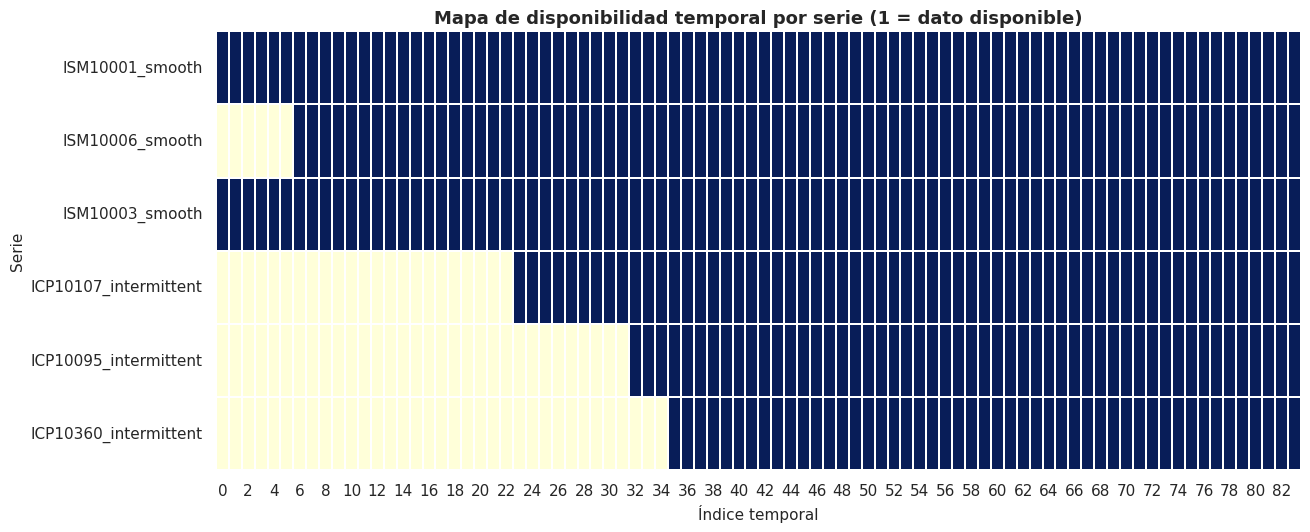

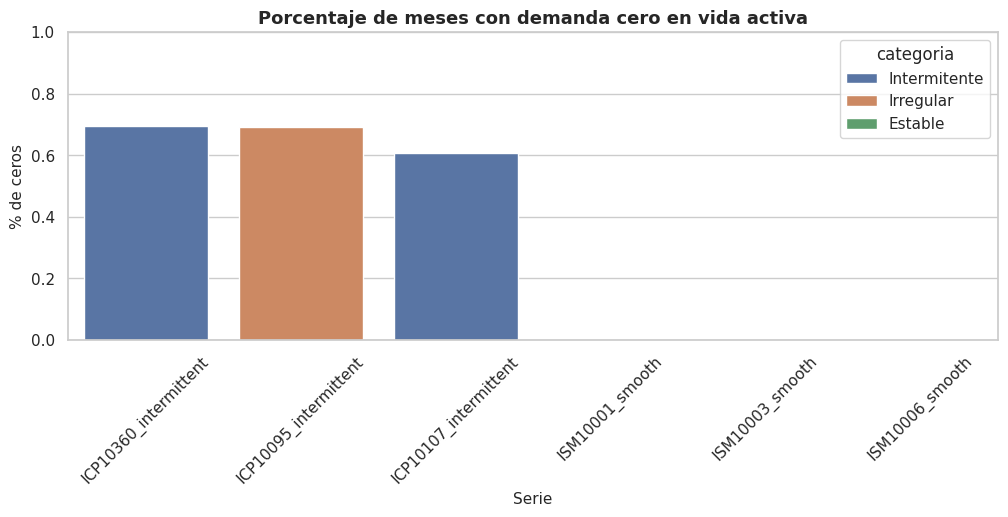

In [ ]:
# Construyo funciones auxiliares para auditar vida activa, ceros y clasificación de demanda.
def get_active_frame(data, target_col):
    first_idx = data[target_col].first_valid_index()
    if first_idx is None:
        return pd.DataFrame(columns=[DATE_COL, target_col] + EXOG_COLS)
    active = data.loc[first_idx:, [DATE_COL, target_col] + EXOG_COLS].copy()
    return active.reset_index(drop=True)

def classify_adi_cv2(y_active):
    y = pd.Series(y_active).dropna().astype(float)
    non_zero = y[y > 0]

    if len(y) == 0:
        return np.nan, np.nan, "Sin datos"

    adi = len(y) / len(non_zero) if len(non_zero) > 0 else np.inf

    if len(non_zero) <= 1 or non_zero.mean() == 0:
        cv2 = 0.0 if len(non_zero) == 1 else np.nan
    else:
        cv2 = (non_zero.std(ddof=1) / non_zero.mean()) ** 2

    if np.isinf(adi):
        categoria = "Sin demanda"
    elif adi < 1.32 and cv2 < 0.49:
        categoria = "Estable"
    elif adi >= 1.32 and cv2 < 0.49:
        categoria = "Intermitente"
    elif adi < 1.32 and cv2 >= 0.49:
        categoria = "Errática"
    else:
        categoria = "Irregular"

    return float(adi), float(cv2) if pd.notna(cv2) else np.nan, categoria

def audit_targets(data, target_cols):
    rows = []
    for target in target_cols:
        active = get_active_frame(data, target)
        if active.empty:
            rows.append({
                "serie": target,
                "inicio_vida_activa": pd.NaT,
                "fin_serie": pd.NaT,
                "n_obs_activas": 0,
                "n_ceros_vida_activa": 0,
                "pct_ceros_vida_activa": np.nan,
                "ADI": np.nan,
                "CV2": np.nan,
                "categoria": "Sin datos",
                "min": np.nan,
                "max": np.nan,
                "media": np.nan,
                "desv_std": np.nan,
            })
            continue

        adi, cv2, categoria = classify_adi_cv2(active[target])

        rows.append({
            "serie": target,
            "inicio_vida_activa": active[DATE_COL].min(),
            "fin_serie": active[DATE_COL].max(),
            "n_obs_activas": int(active[target].notna().sum()),
            "n_ceros_vida_activa": int((active[target] == 0).sum()),
            "pct_ceros_vida_activa": float((active[target] == 0).mean()),
            "ADI": adi,
            "CV2": cv2,
            "categoria": categoria,
            "min": float(active[target].min()),
            "max": float(active[target].max()),
            "media": float(active[target].mean()),
            "desv_std": float(active[target].std(ddof=1)),
        })
    return pd.DataFrame(rows).sort_values("inicio_vida_activa").reset_index(drop=True)

audit_df = audit_targets(df, TARGET_COLS)
audit_lookup = audit_df.set_index("serie").to_dict("index")

display(
    audit_df.style.format({
        "pct_ceros_vida_activa": "{:.1%}",
        "ADI": "{:.3f}",
        "CV2": "{:.3f}",
        "min": "{:,.2f}",
        "max": "{:,.2f}",
        "media": "{:,.2f}",
        "desv_std": "{:,.2f}",
    })
)

resumen_global = pd.DataFrame({
    "n_filas": [df.shape[0]],
    "n_columnas": [df.shape[1]],
    "fecha_min": [df[DATE_COL].min()],
    "fecha_max": [df[DATE_COL].max()],
    "n_targets": [len(TARGET_COLS)],
    "n_exogenas": [len(EXOG_COLS)],
})
display(resumen_global)

# Grafico disponibilidad temporal por serie.
fig, ax = plt.subplots(figsize=(14, 3 + len(TARGET_COLS) * 0.45))
availability = df[TARGET_COLS].notna().T.astype(int)
sns.heatmap(
    availability,
    cmap="YlGnBu",
    cbar=False,
    linewidths=0.2,
    linecolor="white",
    ax=ax,
)
ax.set_title("Mapa de disponibilidad temporal por serie (1 = dato disponible)")
ax.set_xlabel("Índice temporal")
ax.set_ylabel("Serie")
plt.show()

# Grafico porcentaje de ceros en vida activa.
fig, ax = plt.subplots(figsize=(12, 4))
plot_df = audit_df.sort_values("pct_ceros_vida_activa", ascending=False)
sns.barplot(data=plot_df, x="serie", y="pct_ceros_vida_activa", hue="categoria", dodge=False, ax=ax)
ax.set_title("Porcentaje de meses con demanda cero en vida activa")
ax.set_xlabel("Serie")
ax.set_ylabel("% de ceros")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=45)
plt.show()

# **3. Exploración visual y revisión de estacionalidad**

El objetivo aquí es revisar si existen:

- cambios de nivel,
- meses con concentración de demanda,
- indicios de ciclo estacional,
- comportamiento diferencial entre la demanda y las variables exógenas.

No se impone todavía ninguna transformación; primero se observa la estructura.

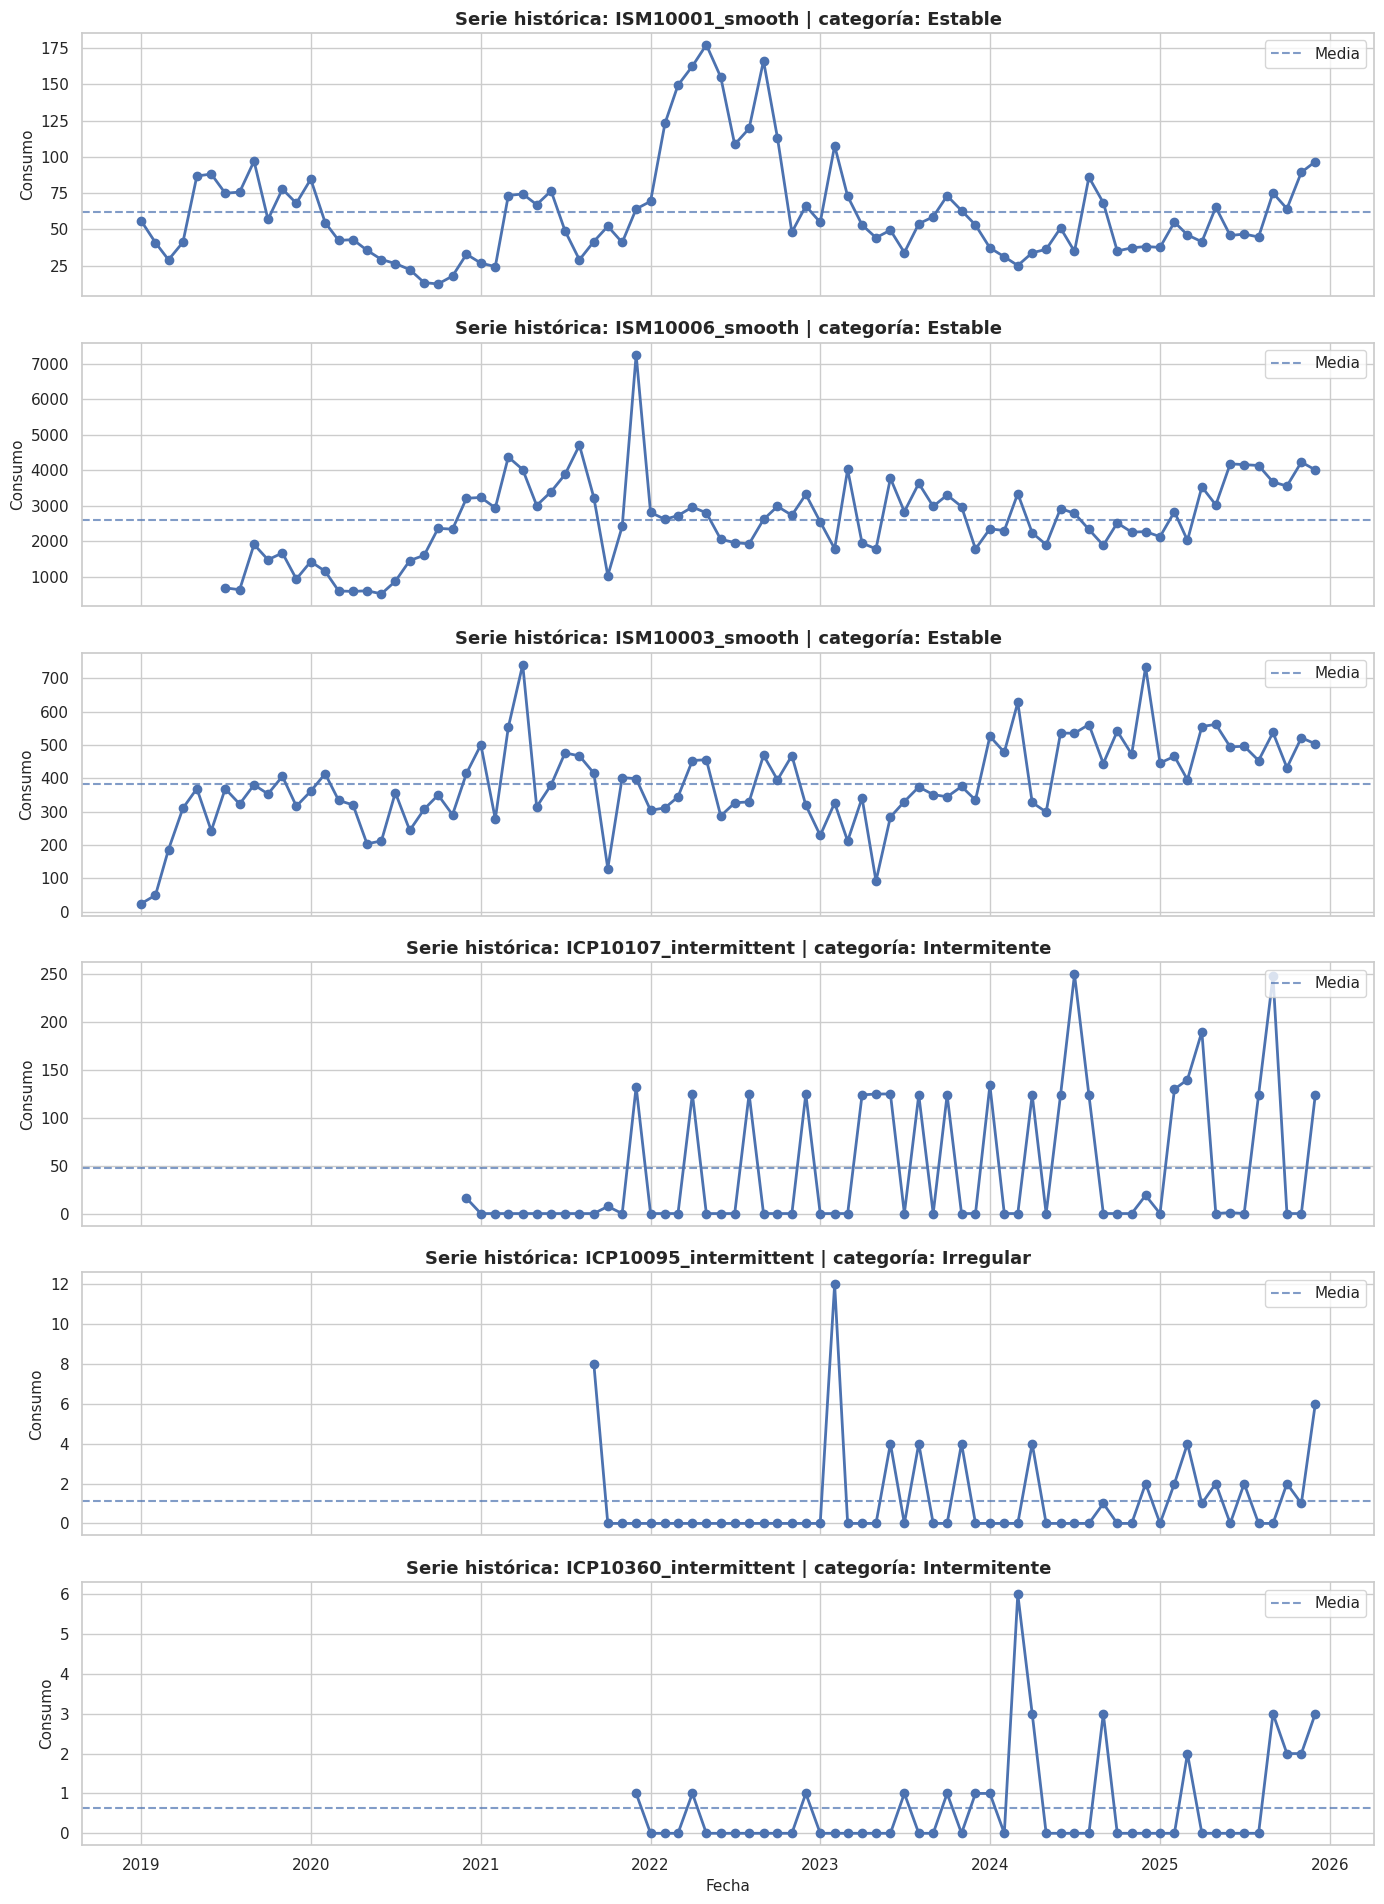

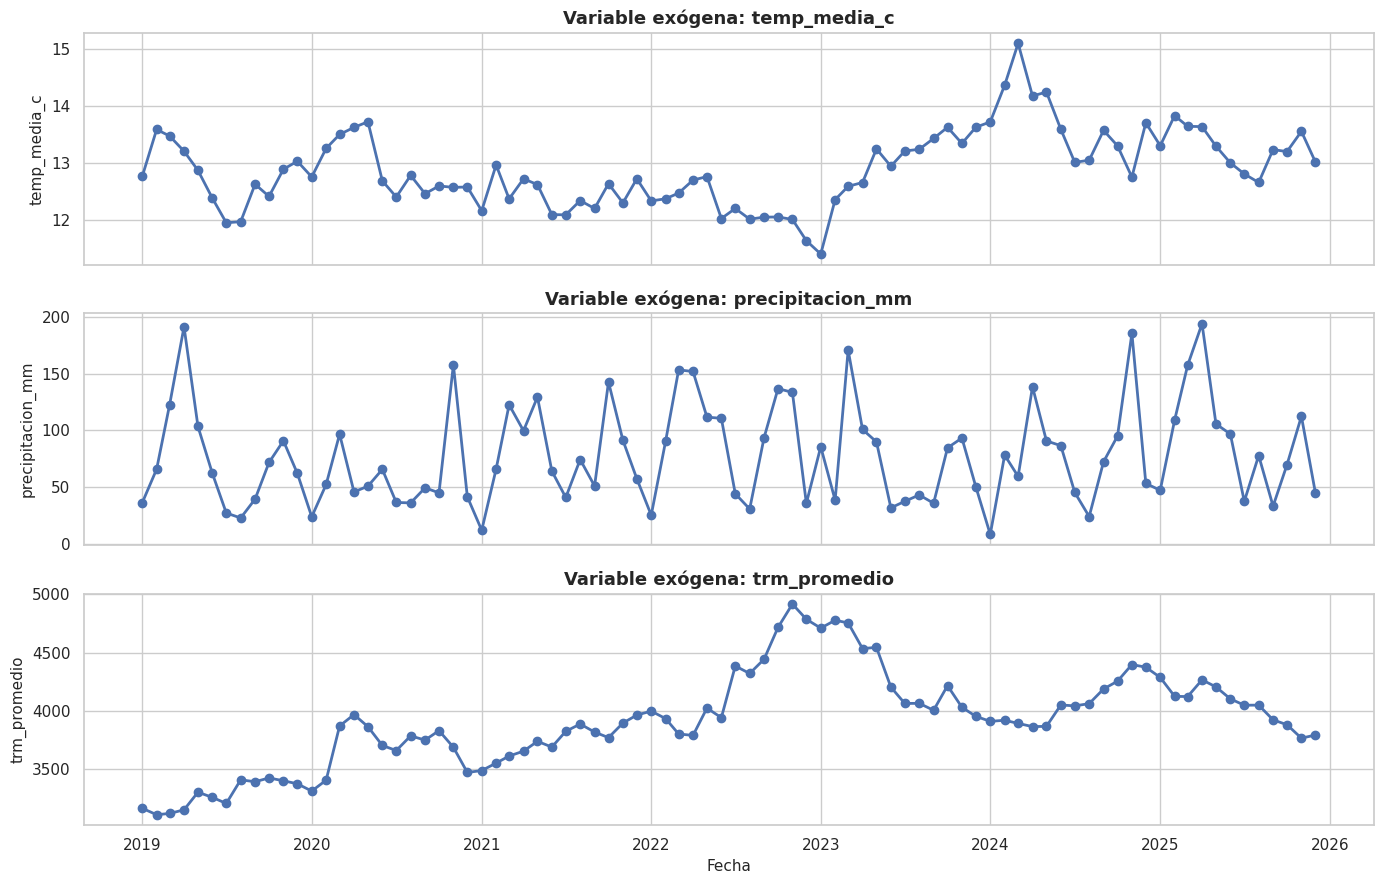

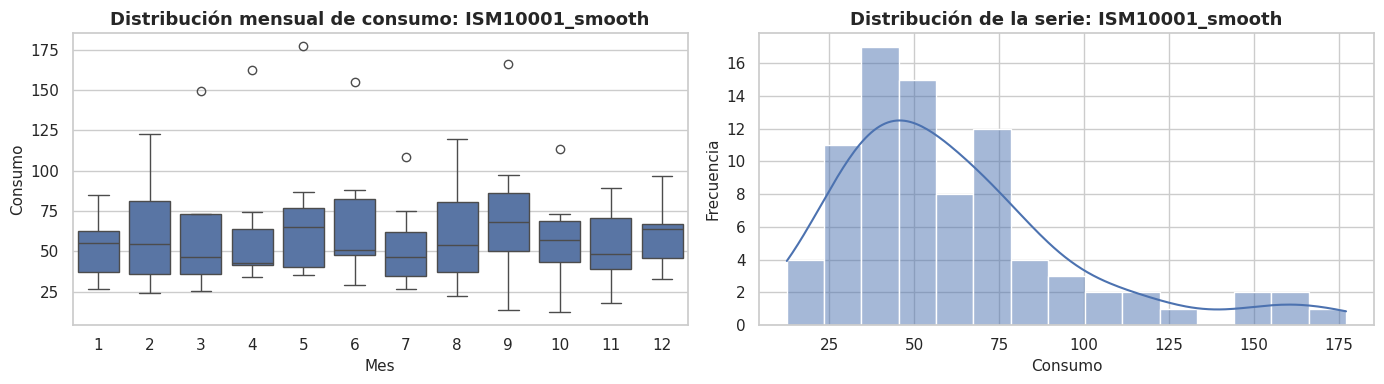

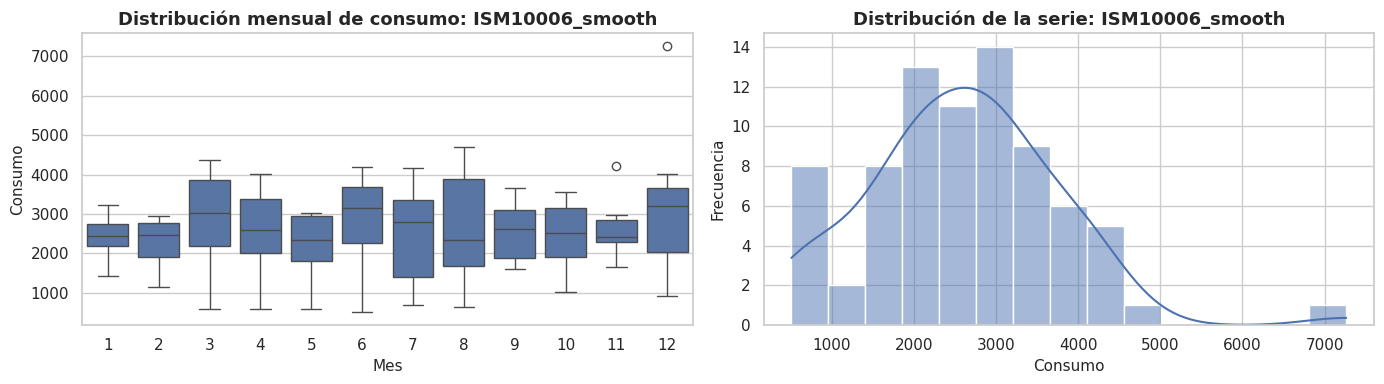

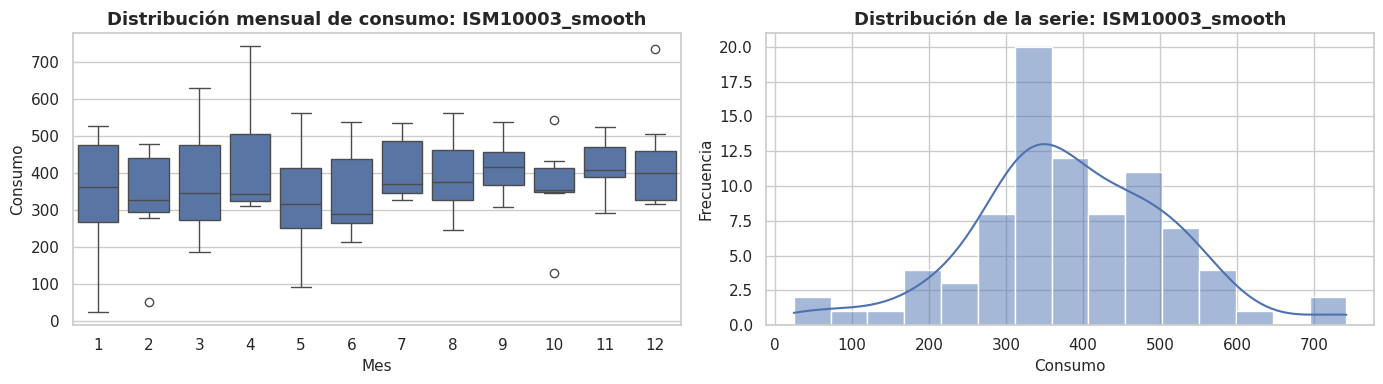

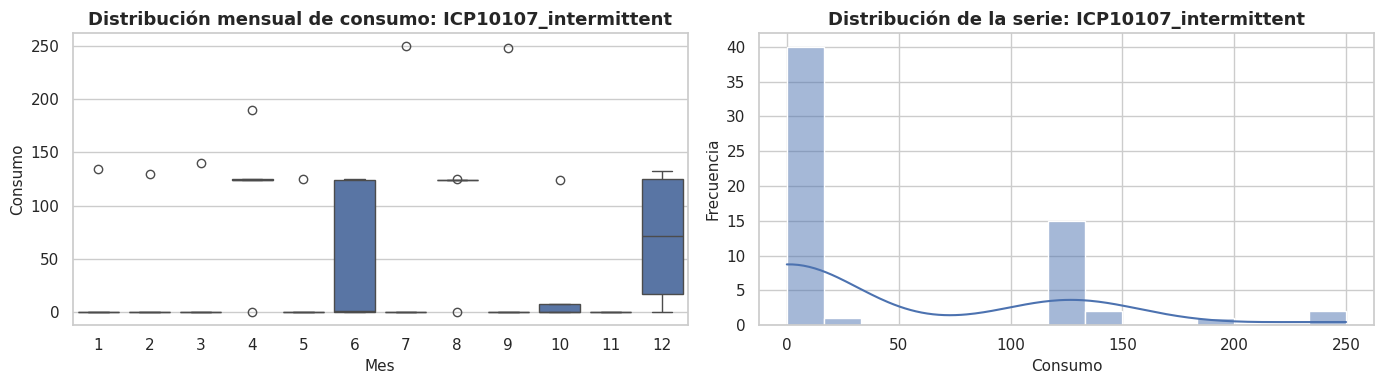

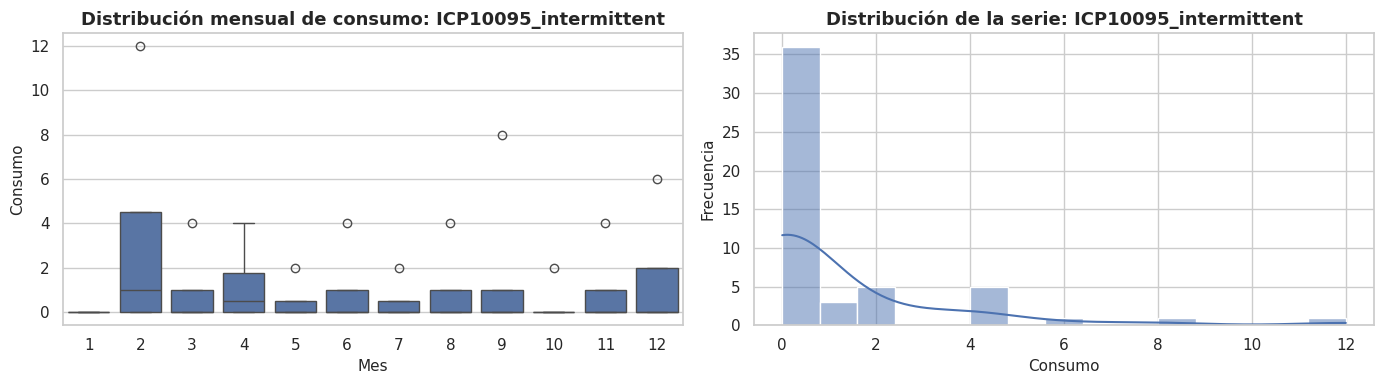

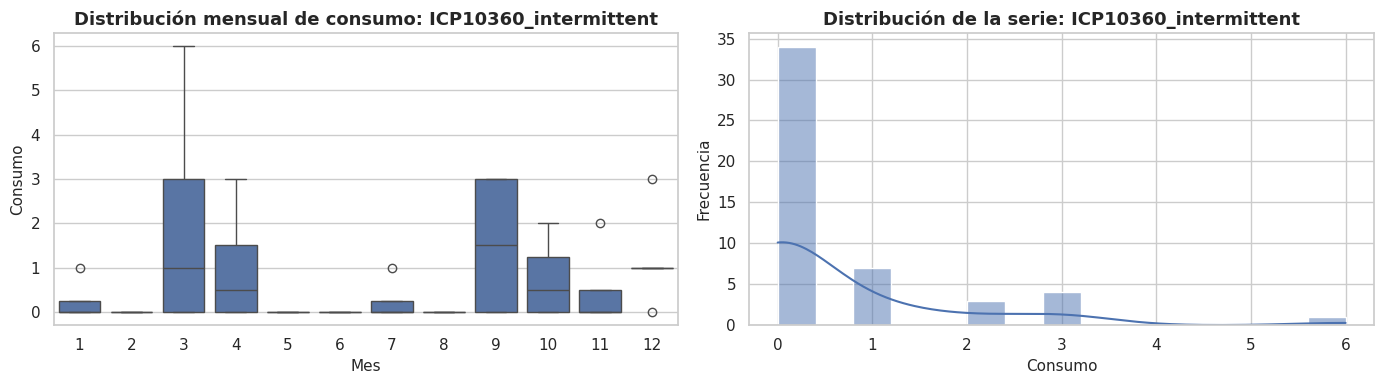

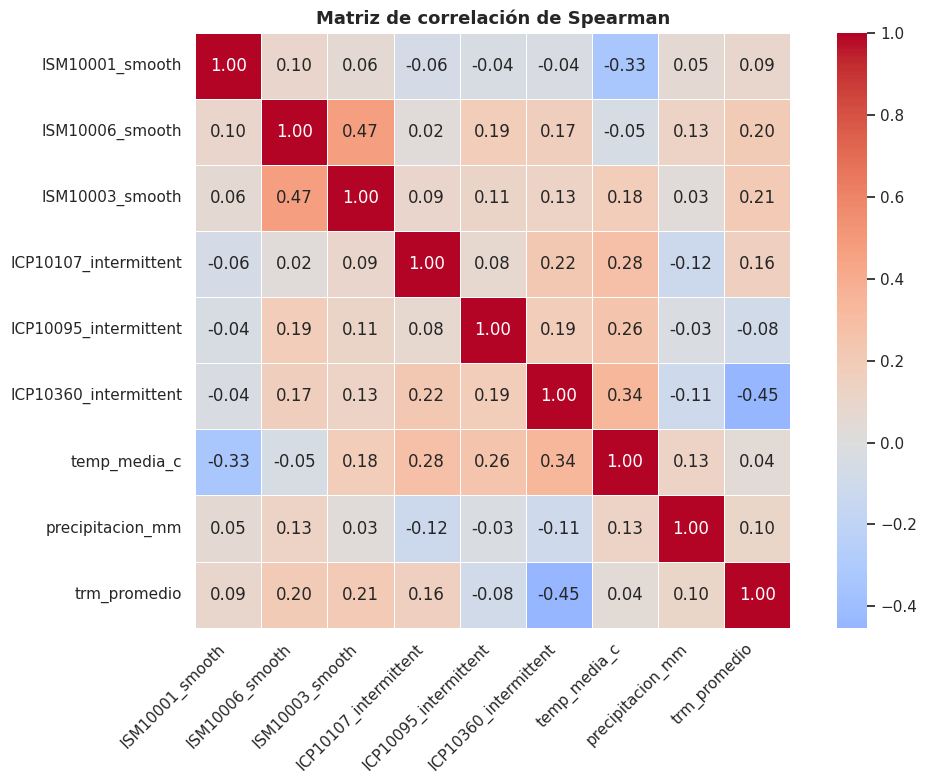

In [ ]:
# Grafico la trayectoria histórica de cada SKU y de las variables exógenas.
n_targets = len(TARGET_COLS)
fig, axes = plt.subplots(n_targets, 1, figsize=(14, 3.2 * n_targets), sharex=True)

if n_targets == 1:
    axes = [axes]

for ax, target in zip(axes, TARGET_COLS):
    active = get_active_frame(df, target)
    ax.plot(active[DATE_COL], active[target], marker="o", linewidth=2)
    ax.set_title(f"Serie histórica: {target} | categoría: {audit_lookup[target]['categoria']}")
    ax.set_ylabel("Consumo")
    ax.axhline(active[target].mean(), linestyle="--", alpha=0.7, label="Media")
    ax.legend(loc="upper right")

plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(len(EXOG_COLS), 1, figsize=(14, 9), sharex=True)
for ax, col in zip(axes, EXOG_COLS):
    ax.plot(df[DATE_COL], df[col], marker="o", linewidth=2)
    ax.set_title(f"Variable exógena: {col}")
    ax.set_ylabel(col)
plt.xlabel("Fecha")
plt.tight_layout()
plt.show()

# Reviso distribución mensual para detectar estacionalidad visible.
for target in TARGET_COLS:
    active = get_active_frame(df, target).copy()
    active["mes"] = active[DATE_COL].dt.month

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.boxplot(data=active, x="mes", y=target, ax=axes[0])
    axes[0].set_title(f"Distribución mensual de consumo: {target}")
    axes[0].set_xlabel("Mes")
    axes[0].set_ylabel("Consumo")

    sns.histplot(active[target], kde=True, bins=15, ax=axes[1])
    axes[1].set_title(f"Distribución de la serie: {target}")
    axes[1].set_xlabel("Consumo")
    axes[1].set_ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# Matriz de correlación de Spearman entre series y exógenas.
corr_df = df[TARGET_COLS + EXOG_COLS].corr(method="spearman")
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    square=True
)
plt.title("Matriz de correlación de Spearman")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **4. Diagnóstico econométrico preliminar**

### 4.1. Qué se contrasta aquí

Para cada serie se revisan al menos cuatro bloques:

1. **Estacionariedad en nivel**  
   - ADF: \(H_0\): la serie tiene raíz unitaria.  
   - KPSS: \(H_0\): la serie es estacionaria.

2. **Fuerza estacional** mediante STL  
   \[
   y_t = T_t + S_t + R_t
   \]
   y se resume con:
   \[
   F_S = \max\left(0,\ 1 - \frac{\mathrm{Var}(R_t)}{\mathrm{Var}(S_t + R_t)}\right)
   \]

3. **Colinealidad exógena** mediante VIF.

4. **Relación contemporánea y con rezagos cortos** entre cada SKU y sus exógenas.

### 4.2. Regla práctica para diferencias

- Se sugiere \(d=1\) cuando ADF no rechaza raíz unitaria o KPSS rechaza estacionariedad.
- Se sugiere \(D=1\) cuando la fuerza estacional o la autocorrelación en rezago 12 apuntan a un patrón anual relevante.

In [ ]:
# Construyo funciones de diagnóstico de estacionariedad, estacionalidad y multicolinealidad.
def seasonal_strength(y, period=12):
    y = pd.Series(y).dropna().astype(float)
    if len(y) < 2 * period:
        return np.nan
    try:
        stl = STL(y, period=period, robust=True).fit()
        denom = np.var(stl.seasonal + stl.resid)
        if denom == 0:
            return np.nan
        return max(0.0, 1.0 - np.var(stl.resid) / denom)
    except Exception:
        return np.nan

def stationarity_summary(y, period=12):
    y = pd.Series(y).dropna().astype(float)
    out = {
        "n_obs": int(len(y)),
        "seasonal_strength": seasonal_strength(y, period=period),
    }

    try:
        out["adf_pvalue"] = float(adfuller(y, autolag="AIC")[1])
    except Exception:
        out["adf_pvalue"] = np.nan

    try:
        out["kpss_pvalue"] = float(kpss(y, regression="c", nlags="auto")[1])
    except Exception:
        out["kpss_pvalue"] = np.nan

    out["d_sugerido"] = int(
        (pd.isna(out["adf_pvalue"]) or out["adf_pvalue"] > 0.05)
        or (pd.notna(out["kpss_pvalue"]) and out["kpss_pvalue"] < 0.05)
    )

    try:
        acf_vals = acf(y, nlags=period, fft=False)
        lag_seasonal = acf_vals[period] if len(acf_vals) > period else 0.0
    except Exception:
        lag_seasonal = 0.0

    out["acf_lag_12"] = float(lag_seasonal)
    out["D_sugerido"] = int(
        (
            (pd.notna(out["seasonal_strength"]) and out["seasonal_strength"] > 0.25)
            or abs(lag_seasonal) > 0.25
        ) and len(y) >= 2 * period
    )
    return out

def lagged_exog_correlations(data, target_col, exog_cols, max_lag=3):
    active = get_active_frame(data, target_col).copy()
    rows = []
    for exog in exog_cols:
        for lag in range(max_lag + 1):
            corr = active[target_col].corr(active[exog].shift(lag), method="spearman")
            rows.append({
                "serie": target_col,
                "exogena": exog,
                "lag": lag,
                "spearman": corr,
            })
    return pd.DataFrame(rows)

diag_rows = []
lag_corr_rows = []

for target in TARGET_COLS:
    active = get_active_frame(df, target)
    diag_rows.append({
        "serie": target,
        "categoria": audit_lookup[target]["categoria"],
        **stationarity_summary(active[target], period=SEASONAL_PERIOD)
    })
    lag_corr_rows.append(lagged_exog_correlations(df, target, EXOG_COLS, max_lag=3))

diagnostic_df = pd.DataFrame(diag_rows)
lag_corr_df = pd.concat(lag_corr_rows, ignore_index=True)

display(
    diagnostic_df.style.format({
        "seasonal_strength": "{:.3f}",
        "adf_pvalue": "{:.4f}",
        "kpss_pvalue": "{:.4f}",
        "acf_lag_12": "{:.3f}",
    })
)

# Calculo VIF sobre exógenas.
X_vif = df[EXOG_COLS].copy().dropna()
X_vif = X_vif.assign(constante=1.0)
vif_df = pd.DataFrame({
    "variable": EXOG_COLS,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(EXOG_COLS))]
})
display(vif_df.style.format({"VIF": "{:.3f}"}))

# Resumo la mayor correlación absoluta por exógena y rezago corto.
lag_corr_summary = (
    lag_corr_df.assign(abs_corr=lambda x: x["spearman"].abs())
    .sort_values(["serie", "abs_corr"], ascending=[True, False])
    .groupby(["serie", "exogena"], as_index=False)
    .first()
    .sort_values(["serie", "abs_corr"], ascending=[True, False])
)
display(lag_corr_summary.style.format({"spearman": "{:.3f}", "abs_corr": "{:.3f}"}))

,serie,categoria,n_obs,seasonal_strength,adf_pvalue,kpss_pvalue,d_sugerido,acf_lag_12,D_sugerido
0,ISM10001_smooth,Estable,84,0.242,0.0391,0.1000,0,-0.061,0
1,ISM10006_smooth,Estable,78,0.082,0.2228,0.0339,1,-0.075,0
2,ISM10003_smooth,Estable,84,0.000,0.2883,0.0100,1,0.032,0
3,ICP10107_intermittent,Intermitente,61,0.000,0.0000,0.0155,1,0.069,0
4,ICP10095_intermittent,Irregular,52,0.000,0.0000,0.1000,0,-0.124,0
5,ICP10360_intermittent,Intermitente,49,0.228,0.0000,0.0963,0,0.104,0


,variable,VIF
0,temp_media_c,1.020
1,precipitacion_mm,1.036
2,trm_promedio,1.034


,serie,exogena,lag,spearman,abs_corr
1,ICP10095_intermittent,temp_media_c,1,0.285,0.285
2,ICP10095_intermittent,trm_promedio,3,0.267,0.267
0,ICP10095_intermittent,precipitacion_mm,2,-0.174,0.174
4,ICP10107_intermittent,temp_media_c,0,0.276,0.276
5,ICP10107_intermittent,trm_promedio,3,0.252,0.252
3,ICP10107_intermittent,precipitacion_mm,2,0.202,0.202
8,ICP10360_intermittent,trm_promedio,0,-0.452,0.452
7,ICP10360_intermittent,temp_media_c,0,0.340,0.340
6,ICP10360_intermittent,precipitacion_mm,3,-0.338,0.338
10,ISM10001_smooth,temp_media_c,1,-0.349,0.349


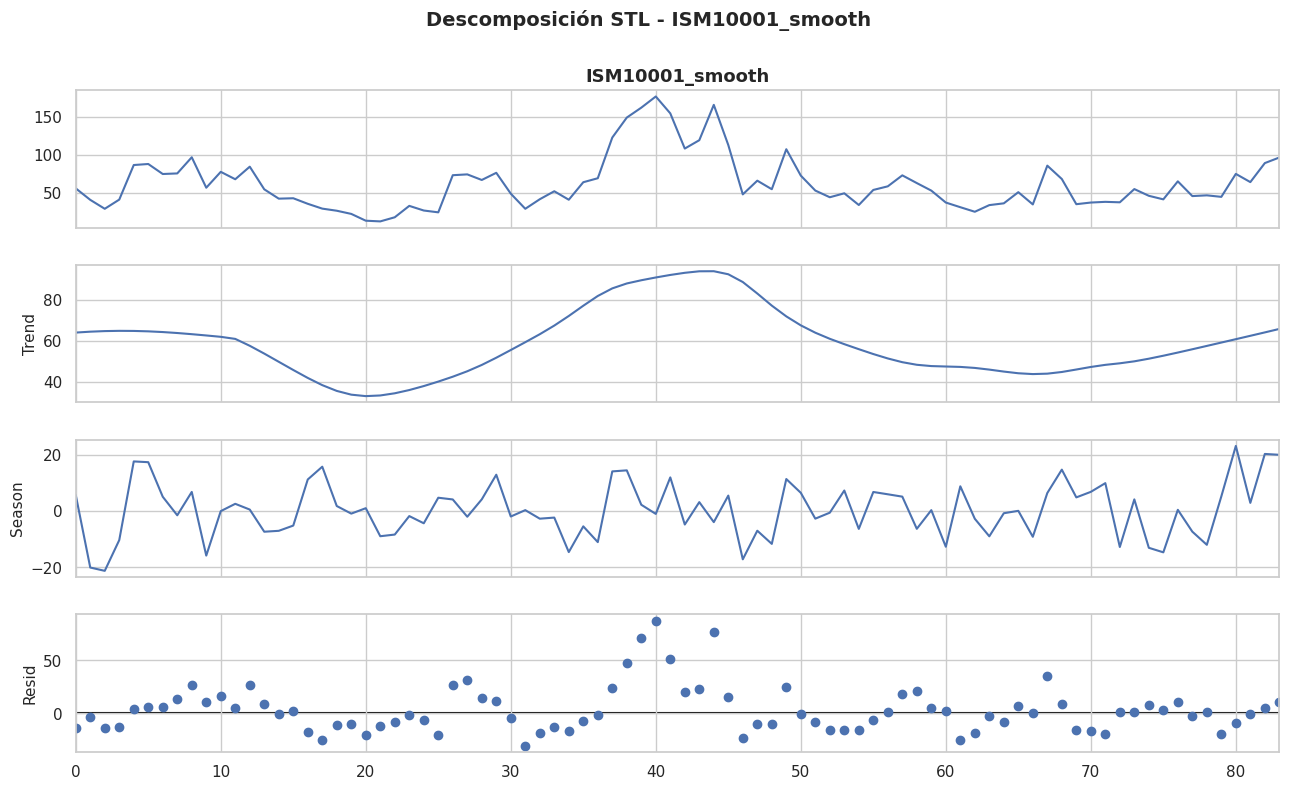

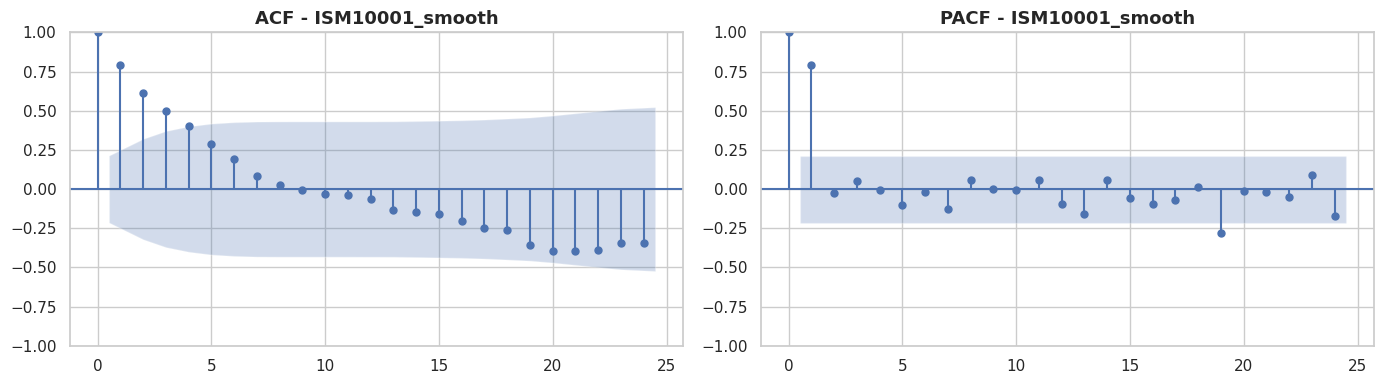

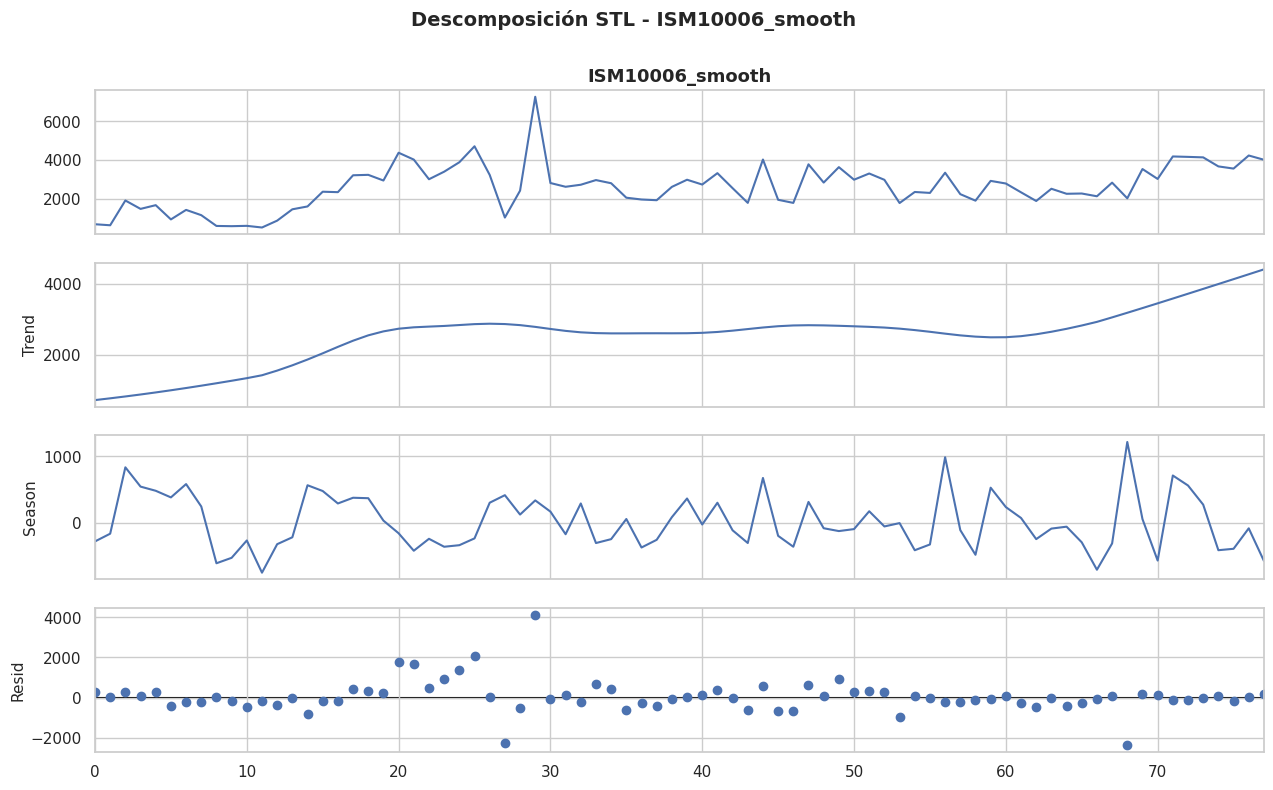

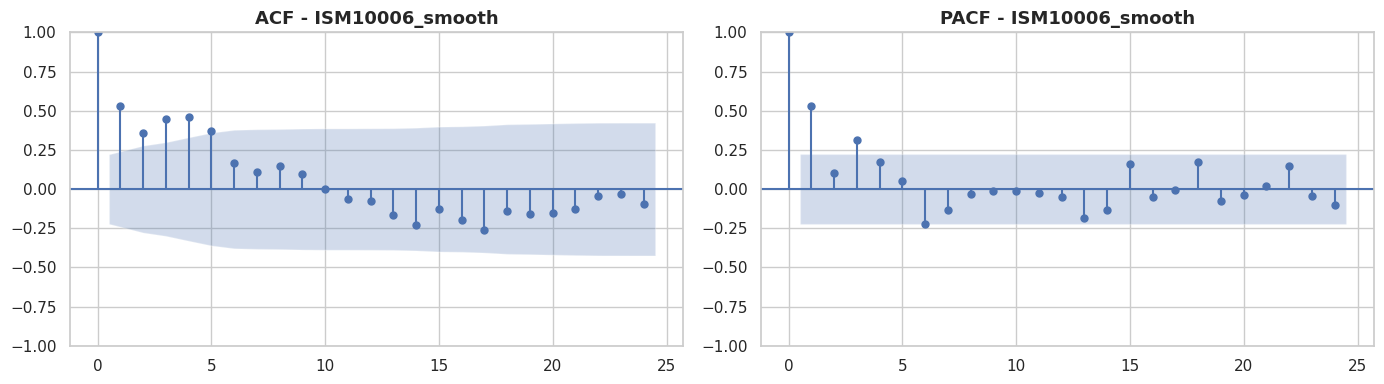

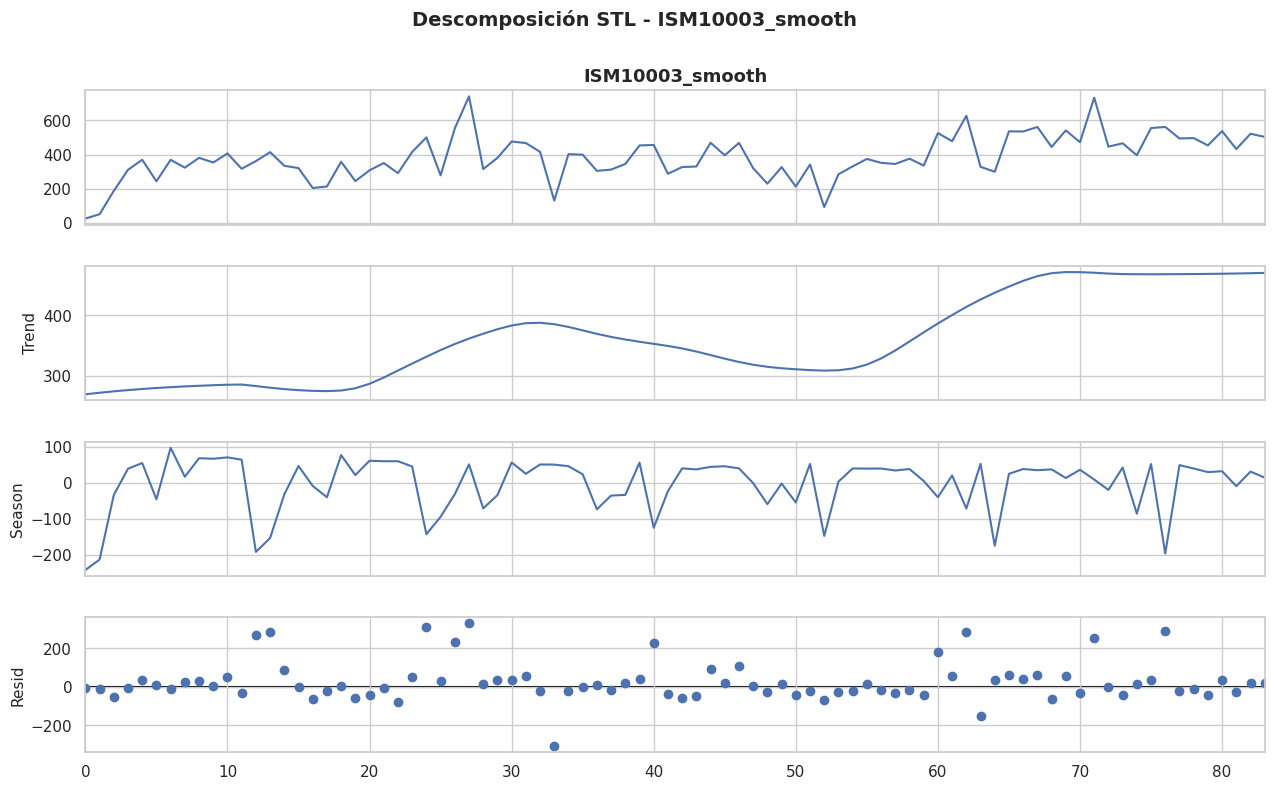

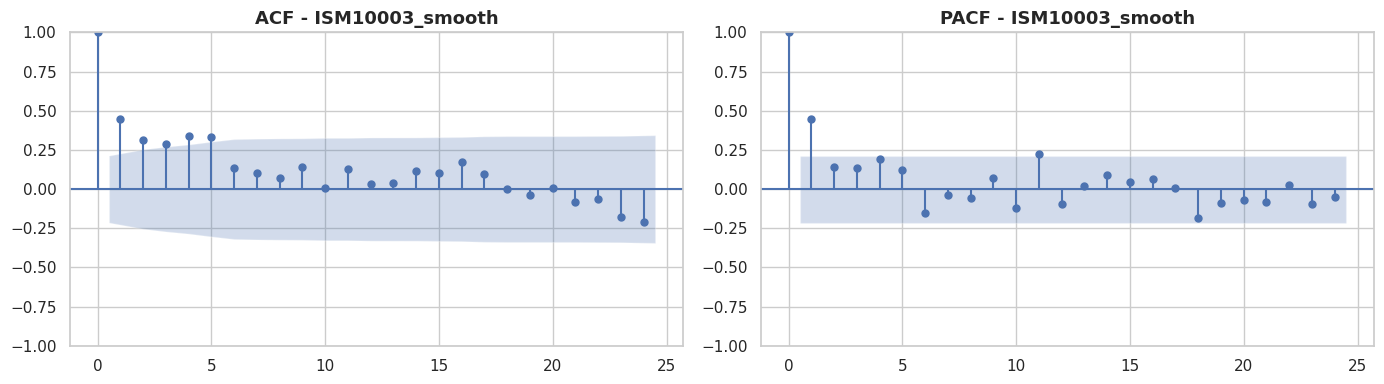

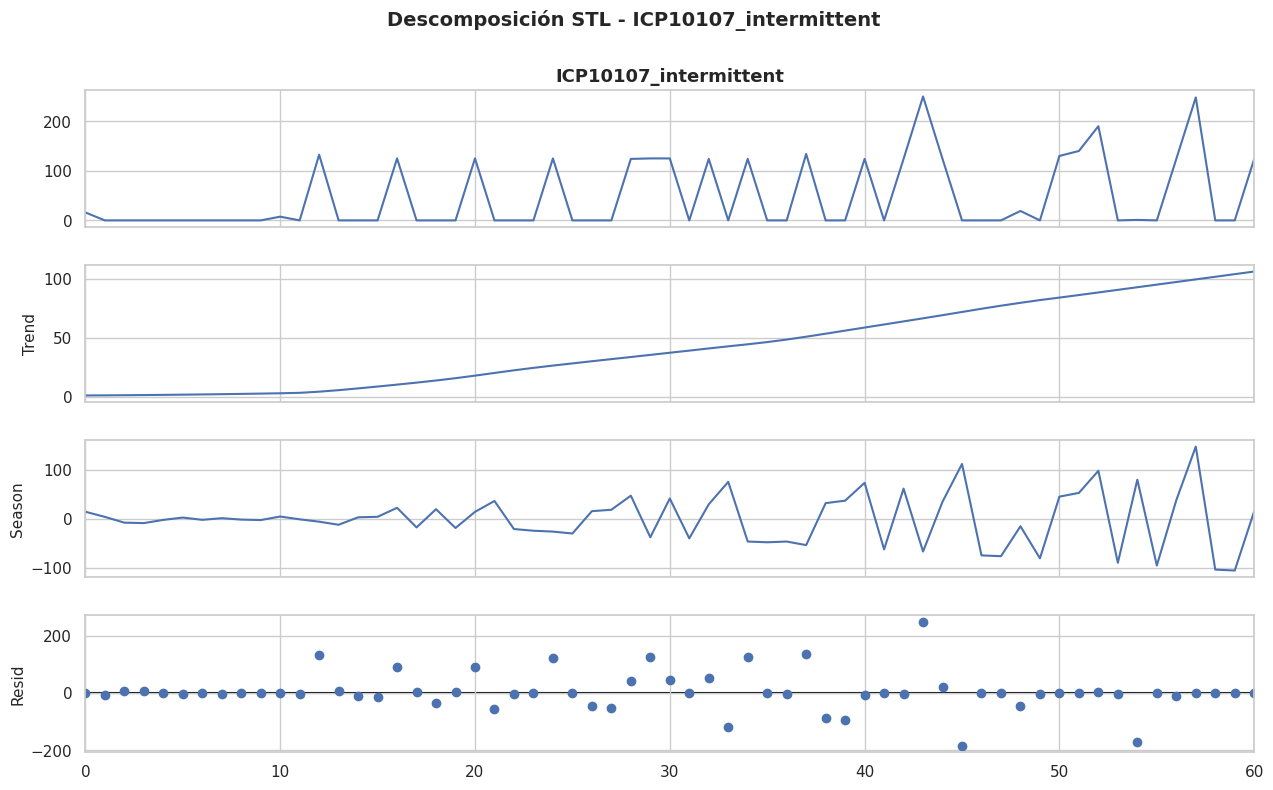

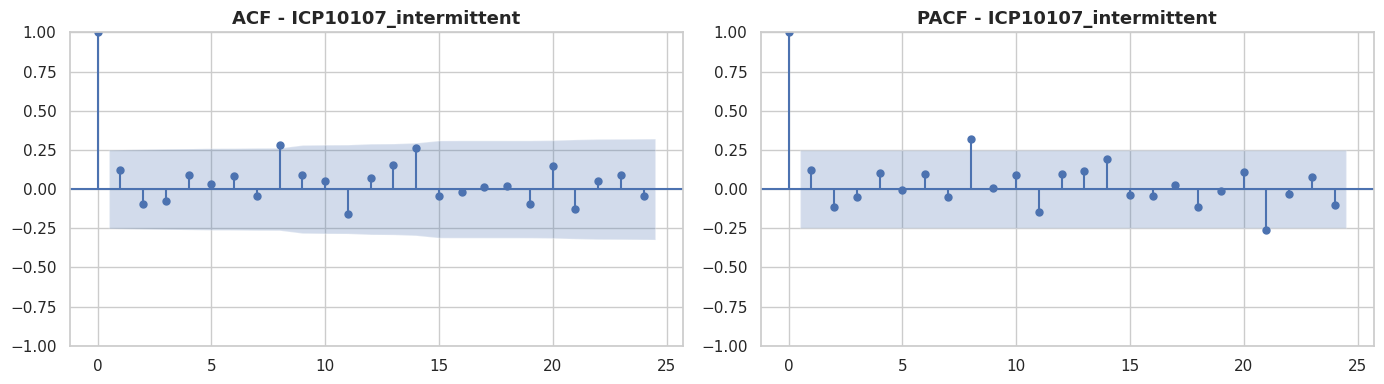

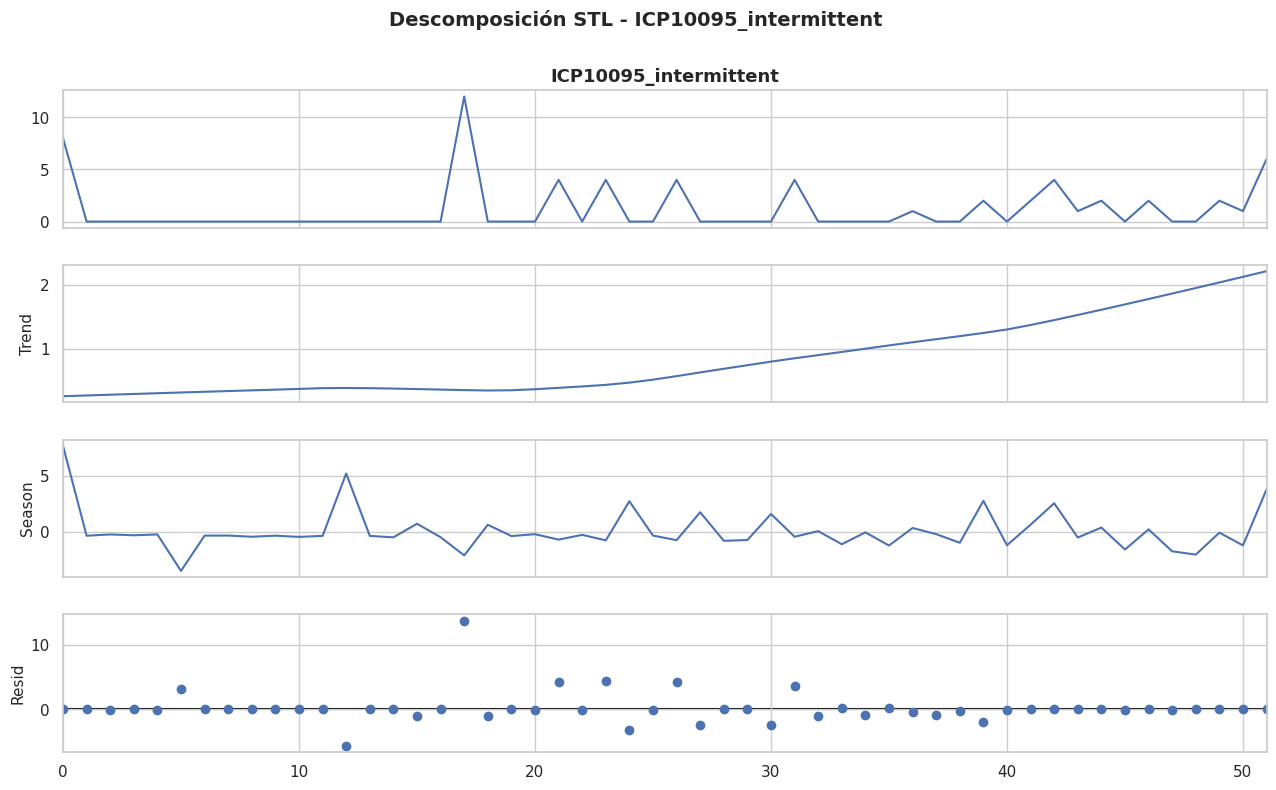

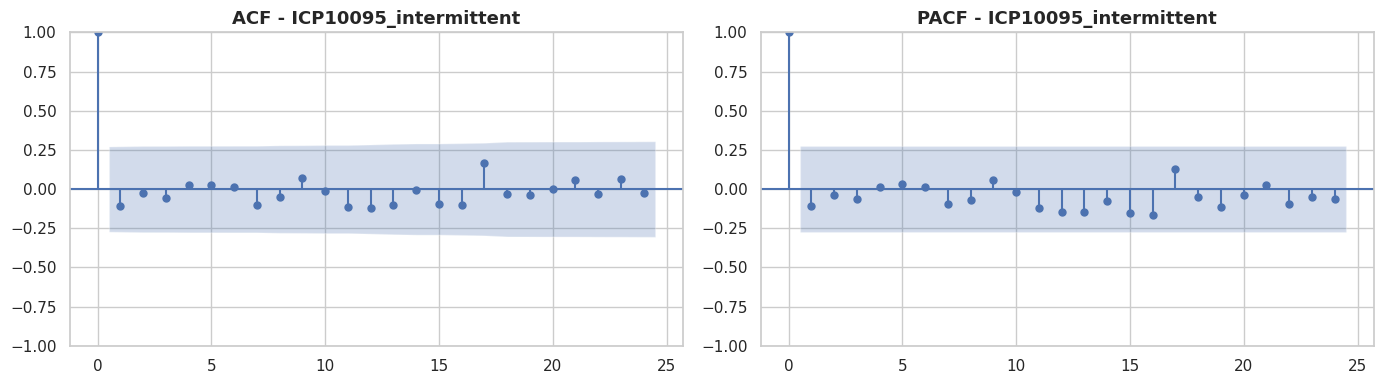

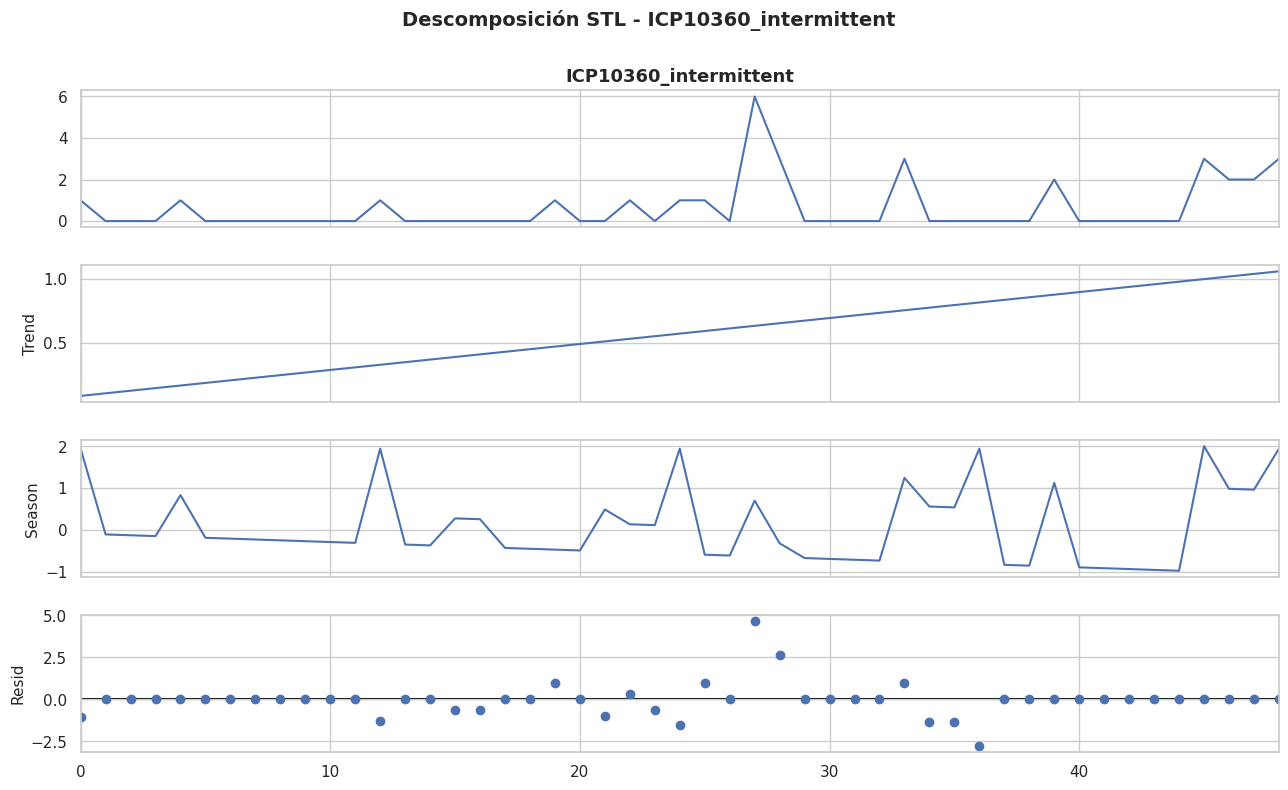

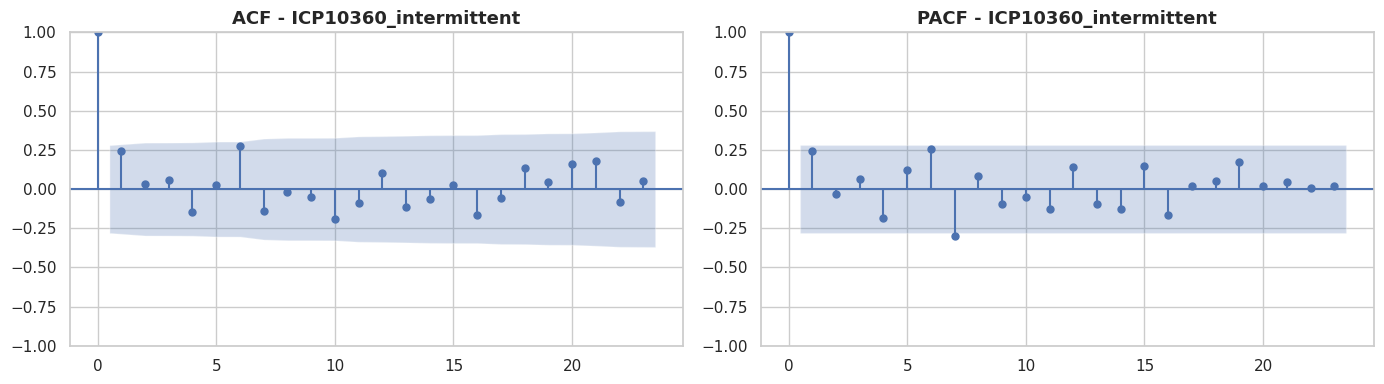

In [ ]:
# Grafico STL y ACF/PACF por serie para revisar estructura temporal de forma visual.
for target in TARGET_COLS:
    active = get_active_frame(df, target)
    y = active[target].astype(float).reset_index(drop=True)

    if len(y) >= 2 * SEASONAL_PERIOD:
        stl = STL(y, period=SEASONAL_PERIOD, robust=True).fit()
        fig = stl.plot()
        fig.set_size_inches(13, 8)
        fig.suptitle(f"Descomposición STL - {target}", y=1.02, fontsize=14, fontweight="bold")
        plt.show()

    max_lags = min(24, max(3, len(y) // 2 - 1))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    plot_acf(y, lags=max_lags, ax=axes[0])
    axes[0].set_title(f"ACF - {target}")
    plot_pacf(y, lags=max_lags, ax=axes[1], method="ywm")
    axes[1].set_title(f"PACF - {target}")
    plt.tight_layout()
    plt.show()

# **5. Diseño de la validación y de las familias de modelos**

### 5.1. Esquema de evaluación

Se usa **rolling-origin con ventana expansiva** sobre los últimos 12 meses.  
En cada iteración el modelo se vuelve a estimar con toda la información disponible hasta \(t-1\) y luego pronostica \(t\).

### 5.2. Familias comparadas

| Familia | Modelos incluidos |
|---|---|
| Benchmark | Naive, Seasonal Naive |
| ETS | SES / Holt / Holt-Winters aditivo |
| ARIMA | ARIMA, SARIMA y SARIMAX |
| Intermittent Forecasting | Croston, SBA y TSB |
| ML | Elastic Net, Random Forest y Gradient Boosting |

### 5.3. Métricas

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{t=1}^{n}(y_t-\hat{y}_t)^2}
$$

$$
\text{MAE} = \frac{1}{n}\sum_{t=1}^{n}|y_t-\hat{y}_t|
$$

$$
\text{sMAPE} = \frac{100}{n}\sum_{t=1}^{n}\frac{2|y_t-\hat{y}_t|}{|y_t|+|\hat{y}_t|}
$$

$$
\text{MASE} = \frac{\frac{1}{n}\sum_{t=1}^{n}|y_t-\hat{y}_t|}{\frac{1}{T-m}\sum_{t=m+1}^{T}|y_t-y_{t-m}|}
$$

La tabla comparativa principal del cuaderno se reporta **por familia**, tomando el mejor modelo dentro de cada familia para cada serie.

In [ ]:
# Defino utilidades de modelado, selección y pronóstico con comentarios operativos.
def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if mask.sum() == 0:
        return 0.0
    return 100 * np.mean(2 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask])

def mase(y_true, y_pred, y_train, m=1):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_train = np.asarray(y_train, dtype=float)
    if len(y_train) <= m:
        return np.nan
    scale = np.mean(np.abs(y_train[m:] - y_train[:-m]))
    if scale == 0:
        return np.nan
    return np.mean(np.abs(y_true - y_pred)) / scale

def compute_metrics(y_true, y_pred, y_train):
    season_m = SEASONAL_PERIOD if len(y_train) >= 2 * SEASONAL_PERIOD else 1
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "sMAPE": float(smape(y_true, y_pred)),
        "MASE": float(mase(y_true, y_pred, y_train, m=season_m)),
    }

def select_ets_spec(y_train):
    y_train = pd.Series(y_train).astype(float)
    candidates = [
        ("SES", {"trend": None, "seasonal": None, "damped_trend": False}),
        ("Holt", {"trend": "add", "seasonal": None, "damped_trend": False}),
    ]

    if len(y_train) >= 2 * SEASONAL_PERIOD:
        candidates.append(
            (
                "HW_add",
                {
                    "trend": "add",
                    "seasonal": "add",
                    "seasonal_periods": SEASONAL_PERIOD,
                    "damped_trend": False,
                },
            )
        )

    ranked = []
    for name, kwargs in candidates:
        try:
            fit = ExponentialSmoothing(
                y_train,
                initialization_method="estimated",
                **kwargs
            ).fit(optimized=True, remove_bias=False)
            ranked.append((fit.aic, name, kwargs))
        except Exception:
            continue

    ranked.sort(key=lambda x: x[0])
    return (ranked[0][1], ranked[0][2]) if ranked else candidates[0]

def fit_ets(y_train, spec):
    _, kwargs = spec
    fit = ExponentialSmoothing(
        pd.Series(y_train).astype(float),
        initialization_method="estimated",
        **kwargs
    ).fit(optimized=True, remove_bias=False)
    return fit

def select_sarimax_spec(y_train, exog_train=None, seasonal=False):
    diag = stationarity_summary(y_train, period=SEASONAL_PERIOD)
    d = diag["d_sugerido"]
    D = diag["D_sugerido"] if seasonal else 0

    nonseasonal_candidates = [(0, d, 1), (1, d, 0), (1, d, 1), (2, d, 0), (0, d, 2)]
    seasonal_candidates = (
        [(0, D, 1, SEASONAL_PERIOD), (1, D, 0, SEASONAL_PERIOD), (1, D, 1, SEASONAL_PERIOD)]
        if seasonal else
        [(0, 0, 0, 0)]
    )

    ranked = []
    for order in nonseasonal_candidates:
        for seas in seasonal_candidates:
            try:
                fit = SARIMAX(
                    pd.Series(y_train).astype(float),
                    exog=exog_train,
                    order=order,
                    seasonal_order=seas,
                    trend="c",
                    enforce_stationarity=False,
                    enforce_invertibility=False,
                ).fit(disp=False)

                if np.isfinite(fit.aic):
                    ranked.append((fit.aic, {"order": order, "seasonal_order": seas}))
            except Exception:
                continue

    ranked.sort(key=lambda x: x[0])
    return ranked[0][1] if ranked else {"order": (1, 1, 0), "seasonal_order": (0, 0, 0, 0)}

def fit_sarimax(y_train, spec, exog_train=None):
    fit = SARIMAX(
        pd.Series(y_train).astype(float),
        exog=exog_train,
        order=spec["order"],
        seasonal_order=spec["seasonal_order"],
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False)
    return fit

def build_feature_frame(df_series, target_col):
    # Construyo rezagos, medias móviles, tendencia y variables cíclicas de calendario.
    work = df_series[[DATE_COL, target_col] + EXOG_COLS].copy().reset_index(drop=True)
    work["t"] = np.arange(len(work))
    work["month"] = work[DATE_COL].dt.month
    work["month_sin"] = np.sin(2 * np.pi * work["month"] / 12)
    work["month_cos"] = np.cos(2 * np.pi * work["month"] / 12)

    for lag in [1, 2, 3, 6, 12]:
        work[f"lag_{lag}"] = work[target_col].shift(lag)

    for window in [3, 6, 12]:
        work[f"roll_mean_{window}"] = work[target_col].shift(1).rolling(window).mean()

    for exog in EXOG_COLS:
        for lag in [0, 1, 2]:
            work[f"{exog}_lag{lag}"] = work[exog].shift(lag)

    return work

def get_ml_models():
    models = {
        "ElasticNet": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", ElasticNet(alpha=0.05, l1_ratio=0.20, random_state=RANDOM_STATE, max_iter=10000)),
        ]),
        "RandomForest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=250,
                max_depth=6,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
            )),
        ]),
        "GradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=2,
                random_state=RANDOM_STATE,
            )),
        ]),
    }
    return models

def croston_forecast(y, horizon=1, alpha=0.10, variant="croston"):
    """
    variant = 'croston', 'sba' o 'tsb'
    """
    y = np.asarray(pd.Series(y).fillna(0.0), dtype=float)

    if len(y) == 0 or np.all(y <= 0):
        return np.zeros(horizon)

    variant = variant.lower()

    if variant == "tsb":
        first_nonzero = np.flatnonzero(y > 0)
        if len(first_nonzero) == 0:
            return np.zeros(horizon)

        z_t = y[first_nonzero[0]]
        p_t = 1.0 if y[first_nonzero[0]] > 0 else 0.0

        for val in y[first_nonzero[0] + 1:]:
            occ = 1.0 if val > 0 else 0.0
            p_t = alpha * occ + (1 - alpha) * p_t
            if occ == 1.0:
                z_t = alpha * val + (1 - alpha) * z_t

        forecast = max(0.0, p_t * z_t)
        return np.repeat(forecast, horizon)

    nz_idx = np.flatnonzero(y > 0)
    first = nz_idx[0]
    z_hat = y[first]
    p_hat = 1.0
    last = first

    for idx in nz_idx[1:]:
        interval = idx - last
        z_hat = alpha * y[idx] + (1 - alpha) * z_hat
        p_hat = alpha * interval + (1 - alpha) * p_hat
        last = idx

    forecast = z_hat / p_hat if p_hat != 0 else 0.0

    if variant == "sba":
        forecast *= max(0.0, 1 - alpha / 2)

    return np.repeat(max(0.0, forecast), horizon)

def rolling_backtest_classical(df_series, target_col, model_name, spec=None, test_size=12):
    y = df_series[target_col].astype(float).reset_index(drop=True)
    X = df_series[EXOG_COLS].reset_index(drop=True)
    dates = df_series[DATE_COL].reset_index(drop=True)
    first_test = len(y) - test_size

    preds, actuals, bt_dates = [], [], []

    for i in range(first_test, len(y)):
        y_train = y.iloc[:i]
        X_train = X.iloc[:i]
        X_test = X.iloc[i:i+1]

        try:
            if model_name == "Naive":
                pred = float(y_train.iloc[-1])

            elif model_name == "SeasonalNaive":
                pred = float(y_train.iloc[-SEASONAL_PERIOD]) if len(y_train) >= SEASONAL_PERIOD else float(y_train.iloc[-1])

            elif model_name == "ETS":
                pred = float(fit_ets(y_train, spec).forecast(1).iloc[0])

            elif model_name in ("ARIMA", "SARIMA"):
                pred = float(fit_sarimax(y_train, spec).get_forecast(steps=1).predicted_mean.iloc[0])

            elif model_name == "SARIMAX":
                pred = float(
                    fit_sarimax(y_train, spec, exog_train=X_train)
                    .get_forecast(steps=1, exog=X_test)
                    .predicted_mean.iloc[0]
                )

            else:
                raise ValueError(f"Modelo no soportado: {model_name}")

        except Exception:
            pred = float(y_train.iloc[-1])

        preds.append(max(0.0, pred))
        actuals.append(float(y.iloc[i]))
        bt_dates.append(dates.iloc[i])

    train_hist = y.iloc[:first_test].values
    return {
        "preds": np.array(preds),
        "actuals": np.array(actuals),
        "dates": bt_dates,
        "train_hist": train_hist,
    }

def rolling_backtest_intermittent(df_series, target_col, model_name, spec=None, test_size=12):
    y = df_series[target_col].astype(float).reset_index(drop=True)
    dates = df_series[DATE_COL].reset_index(drop=True)
    first_test = len(y) - test_size

    preds, actuals, bt_dates = [], [], []

    variant = spec["variant"]
    alpha = spec["alpha"]

    for i in range(first_test, len(y)):
        y_train = y.iloc[:i]
        pred = float(croston_forecast(y_train, horizon=1, alpha=alpha, variant=variant)[0])

        preds.append(max(0.0, pred))
        actuals.append(float(y.iloc[i]))
        bt_dates.append(dates.iloc[i])

    train_hist = y.iloc[:first_test].values
    return {
        "preds": np.array(preds),
        "actuals": np.array(actuals),
        "dates": bt_dates,
        "train_hist": train_hist,
    }

def rolling_backtest_ml(df_series, target_col, model_name, model, test_size=12):
    feat = build_feature_frame(df_series, target_col)
    feature_cols = [c for c in feat.columns if c not in [DATE_COL, target_col]]

    valid_feature_start = feat[feature_cols].dropna().index.min()
    if pd.isna(valid_feature_start):
        raise ValueError(f"No hay suficientes rezagos para entrenar el modelo {model_name} en {target_col}")

    start_idx = max(SEASONAL_PERIOD, int(valid_feature_start))
    first_test = len(feat) - test_size

    if first_test <= start_idx:
        raise ValueError(f"Backtesting insuficiente para {model_name} en {target_col}")

    preds, actuals, bt_dates = [], [], []

    for i in range(first_test, len(feat)):
        train = feat.loc[start_idx:i-1].dropna(subset=feature_cols + [target_col]).copy()
        X_train = train[feature_cols]
        y_train = train[target_col]
        X_test = feat.loc[[i], feature_cols]

        mdl = clone(model)
        mdl.fit(X_train, y_train)
        pred = float(mdl.predict(X_test)[0])

        preds.append(max(0.0, pred))
        actuals.append(float(feat.loc[i, target_col]))
        bt_dates.append(feat.loc[i, DATE_COL])

    train_hist = feat.loc[:first_test-1, target_col].dropna().values
    return {
        "preds": np.array(preds),
        "actuals": np.array(actuals),
        "dates": bt_dates,
        "train_hist": train_hist,
    }

def build_model_registry(df_series, target_col, test_size=12):
    initial_train = df_series.iloc[:-test_size].copy()
    categoria = audit_lookup[target_col]["categoria"]

    registry = {
        "Naive": {
            "familia": "Benchmark",
            "spec": None,
        },
        "SeasonalNaive": {
            "familia": "Benchmark",
            "spec": None,
        },
        "ETS": {
            "familia": "ETS",
            "spec": select_ets_spec(initial_train[target_col]),
        },
        "ARIMA": {
            "familia": "ARIMA",
            "spec": select_sarimax_spec(initial_train[target_col], seasonal=False),
        },
        "SARIMA": {
            "familia": "ARIMA",
            "spec": select_sarimax_spec(initial_train[target_col], seasonal=True),
        },
        "SARIMAX": {
            "familia": "ARIMA",
            "spec": select_sarimax_spec(
                initial_train[target_col],
                exog_train=initial_train[EXOG_COLS],
                seasonal=True,
            ),
        },
    }

    if categoria in ("Intermitente", "Irregular"):
        registry.update({
            "Croston": {
                "familia": "Intermittent",
                "spec": {"alpha": 0.10, "variant": "croston"},
            },
            "SBA": {
                "familia": "Intermittent",
                "spec": {"alpha": 0.10, "variant": "sba"},
            },
            "TSB": {
                "familia": "Intermittent",
                "spec": {"alpha": 0.10, "variant": "tsb"},
            },
        })

    return registry

def build_future_exog(master_df, horizon):
    # Construyo un escenario base de exógenas futuras:
    # clima = climatología mensual histórica;
    # TRM = promedio de los últimos 6 meses observados.
    last_date = master_df[DATE_COL].max()
    future_dates = pd.date_range(
        last_date + pd.offsets.MonthBegin(1),
        periods=horizon,
        freq="MS"
    )

    month_climatology = master_df.groupby(master_df[DATE_COL].dt.month)[["temp_media_c", "precipitacion_mm"]].mean()
    trm_base = float(master_df["trm_promedio"].tail(6).mean())

    future = pd.DataFrame({DATE_COL: future_dates})
    future["month"] = future[DATE_COL].dt.month
    future["temp_media_c"] = future["month"].map(month_climatology["temp_media_c"])
    future["precipitacion_mm"] = future["month"].map(month_climatology["precipitacion_mm"])
    future["trm_promedio"] = trm_base

    return future.drop(columns="month")

def recursive_ml_forecast(df_series, target_col, model_name, model, future_exog, horizon):
    # Reentreno sobre toda la historia y proyecto de manera recursiva un paso adelante.
    history = df_series[[DATE_COL, target_col] + EXOG_COLS].copy().reset_index(drop=True)
    preds = []

    for step in range(horizon):
        feat = build_feature_frame(history, target_col)
        feature_cols = [c for c in feat.columns if c not in [DATE_COL, target_col]]
        train = feat.dropna(subset=feature_cols + [target_col]).copy()

        mdl = clone(model)
        mdl.fit(train[feature_cols], train[target_col])

        new_row = pd.DataFrame({
            DATE_COL: [future_exog.iloc[step][DATE_COL]],
            target_col: [np.nan],
            "temp_media_c": [future_exog.iloc[step]["temp_media_c"]],
            "precipitacion_mm": [future_exog.iloc[step]["precipitacion_mm"]],
            "trm_promedio": [future_exog.iloc[step]["trm_promedio"]],
        })

        extended = pd.concat([history, new_row], ignore_index=True)
        feat_extended = build_feature_frame(extended, target_col)
        feature_cols = [c for c in feat_extended.columns if c not in [DATE_COL, target_col]]
        X_next = feat_extended.loc[[len(feat_extended) - 1], feature_cols]

        pred = max(0.0, float(mdl.predict(X_next)[0]))
        preds.append(pred)

        new_row[target_col] = pred
        history = pd.concat([history, new_row], ignore_index=True)

    return np.array(preds)

def forecast_benchmark(df_series, target_col, model_name, horizon):
    y = df_series[target_col].astype(float).reset_index(drop=True)

    if model_name == "Naive":
        return np.repeat(float(y.iloc[-1]), horizon)

    seasonal_values = []
    for h in range(1, horizon + 1):
        if len(y) >= SEASONAL_PERIOD:
            idx = len(y) - SEASONAL_PERIOD + ((h - 1) % SEASONAL_PERIOD)
            seasonal_values.append(float(y.iloc[idx]))
        else:
            seasonal_values.append(float(y.iloc[-1]))

    return np.array(seasonal_values)

def residual_diagnostics(residuals):
    residuals = pd.Series(residuals).dropna().astype(float)
    out = {"n_residuos": int(len(residuals))}

    if len(residuals) < 8:
        out.update({
            "ljung_box_pvalue": np.nan,
            "jarque_bera_pvalue": np.nan,
            "arch_lm_pvalue": np.nan,
        })
        return out

    lb_lags = min(12, max(1, len(residuals) // 3))

    try:
        out["ljung_box_pvalue"] = float(
            acorr_ljungbox(residuals, lags=[lb_lags], return_df=True)["lb_pvalue"].iloc[0]
        )
    except Exception:
        out["ljung_box_pvalue"] = np.nan

    try:
        out["jarque_bera_pvalue"] = float(jarque_bera(residuals).pvalue)
    except Exception:
        out["jarque_bera_pvalue"] = np.nan

    try:
        out["arch_lm_pvalue"] = float(het_arch(residuals)[1])
    except Exception:
        out["arch_lm_pvalue"] = np.nan

    return out

In [ ]:
# Ejecuto la comparación de modelos por serie y guardo resultados completos.
ml_models = get_ml_models()

results_rows = []
backtest_store = {}
model_registry_store = {}

for target in TARGET_COLS:
    print(f"Procesando serie: {target}")
    df_series = get_active_frame(df, target)
    registry = build_model_registry(df_series, target, test_size=BACKTEST_STEPS)
    model_registry_store[target] = registry

    for model_name, meta in registry.items():
        try:
            if model_name in ("Croston", "SBA", "TSB"):
                bt = rolling_backtest_intermittent(
                    df_series=df_series,
                    target_col=target,
                    model_name=model_name,
                    spec=meta["spec"],
                    test_size=BACKTEST_STEPS,
                )
            else:
                bt = rolling_backtest_classical(
                    df_series=df_series,
                    target_col=target,
                    model_name=model_name,
                    spec=meta["spec"],
                    test_size=BACKTEST_STEPS,
                )

            backtest_store[(target, model_name)] = bt
            met = compute_metrics(bt["actuals"], bt["preds"], bt["train_hist"])

            results_rows.append({
                "serie": target,
                "modelo": model_name,
                "familia": meta["familia"],
                **met
            })

        except Exception as e:
            print(f"  - {model_name} falló en {target}: {e}")

    for model_name, model in ml_models.items():
        try:
            bt = rolling_backtest_ml(
                df_series=df_series,
                target_col=target,
                model_name=model_name,
                model=model,
                test_size=BACKTEST_STEPS
            )
            backtest_store[(target, model_name)] = bt
            met = compute_metrics(bt["actuals"], bt["preds"], bt["train_hist"])

            results_rows.append({
                "serie": target,
                "modelo": model_name,
                "familia": "ML",
                **met
            })

        except Exception as e:
            print(f"  - {model_name} falló en {target}: {e}")

results_df = pd.DataFrame(results_rows).sort_values(["serie", "RMSE", "MAE"]).reset_index(drop=True)

display(
    results_df.style.format({
        "MAE": "{:,.2f}",
        "RMSE": "{:,.2f}",
        "sMAPE": "{:.2f}",
        "MASE": "{:.3f}",
    })
)

Procesando serie: ISM10001_smooth
Procesando serie: ISM10006_smooth
Procesando serie: ISM10003_smooth
Procesando serie: ICP10107_intermittent
Procesando serie: ICP10095_intermittent
Procesando serie: ICP10360_intermittent


,serie,modelo,familia,MAE,RMSE,sMAPE,MASE
0,ICP10095_intermittent,SBA,Intermittent,1.34,1.79,95.86,0.594
1,ICP10095_intermittent,Croston,Intermittent,1.34,1.79,94.30,0.594
2,ICP10095_intermittent,TSB,Intermittent,1.48,1.85,96.98,0.658
3,ICP10095_intermittent,ETS,ETS,1.35,1.87,111.04,0.598
4,ICP10095_intermittent,SARIMA,ARIMA,1.51,1.88,124.93,0.673
5,ICP10095_intermittent,RandomForest,ML,1.55,1.93,117.71,0.689
6,ICP10095_intermittent,ARIMA,ARIMA,1.40,1.94,123.35,0.624
7,ICP10095_intermittent,ElasticNet,ML,1.40,1.95,118.91,0.623
8,ICP10095_intermittent,SARIMAX,ARIMA,1.72,2.21,149.17,0.764
9,ICP10095_intermittent,SeasonalNaive,Benchmark,1.75,2.22,180.00,0.778


# **6. Tabla comparativa por familia**

La tabla siguiente resume la comparación principal **por familia**.  
El procedimiento es:

1. Dentro de cada familia, se toma el modelo con menor RMSE para cada serie.
2. Luego se promedian las métricas entre las series donde esa familia fue aplicable.
3. Se reporta además cuál fue el modelo representativo más frecuente dentro de cada familia.

,familia,n_series,RMSE_promedio,MAE_promedio,sMAPE_promedio,MASE_promedio,modelo_representativo
0,Intermittent,3,31.67,28.75,135.35,1.358,SBA
1,ML,6,130.91,106.48,77.13,0.759,RandomForest
2,ARIMA,6,140.72,112.69,76.77,0.811,SARIMA
3,ETS,6,144.24,118.54,77.00,0.856,ETS
4,Benchmark,6,156.96,118.26,83.84,0.842,Naive


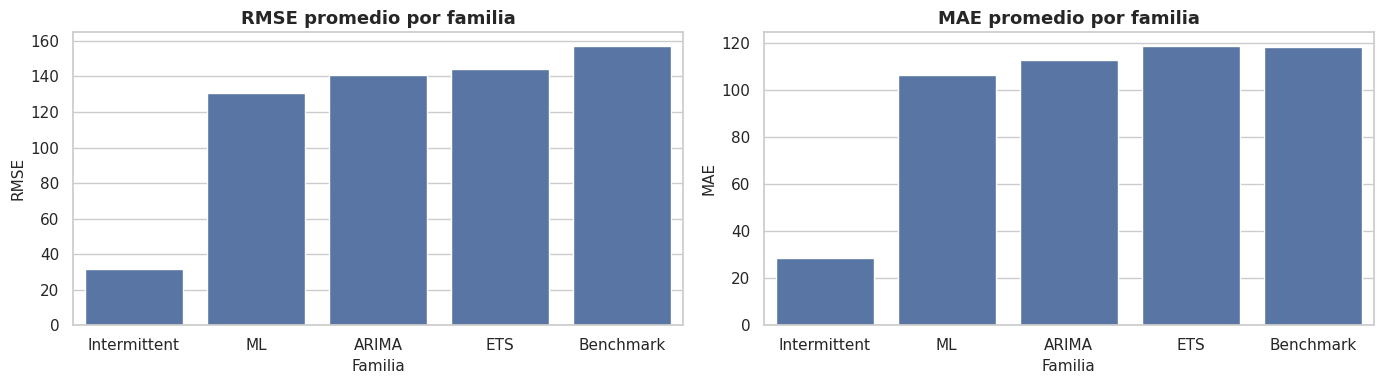

,serie,modelo,familia,MAE,RMSE,sMAPE,MASE
0,ICP10095_intermittent,SBA,Intermittent,1.3365,1.7874,95.8622,0.5940
1,ICP10107_intermittent,ETS,ETS,83.4830,89.3167,131.0039,2.0116
2,ICP10360_intermittent,RandomForest,ML,0.6441,0.9567,148.6151,0.8475
3,ISM10001_smooth,ETS,ETS,12.1956,15.5127,20.9294,0.2639
4,ISM10003_smooth,RandomForest,ML,40.0915,46.6405,8.3282,0.2771
5,ISM10006_smooth,GradientBoosting,ML,497.4073,625.5440,15.7232,0.3865


In [ ]:
# Resumo resultados por familia tomando el mejor modelo de esa familia en cada serie.
family_best_df = (
    results_df
    .dropna(subset=["RMSE", "MAE"])
    .sort_values(["serie", "familia", "RMSE", "MAE"])
    .groupby(["serie", "familia"], as_index=False)
    .first()
)

family_summary = (
    family_best_df
    .groupby("familia", as_index=False)
    .agg(
        n_series=("serie", "nunique"),
        RMSE_promedio=("RMSE", "mean"),
        MAE_promedio=("MAE", "mean"),
        sMAPE_promedio=("sMAPE", "mean"),
        MASE_promedio=("MASE", "mean"),
        modelo_representativo=("modelo", lambda s: s.value_counts().index[0]),
    )
    .sort_values("RMSE_promedio")
    .reset_index(drop=True)
)

display(
    family_summary.style.format({
        "RMSE_promedio": "{:,.2f}",
        "MAE_promedio": "{:,.2f}",
        "sMAPE_promedio": "{:.2f}",
        "MASE_promedio": "{:.3f}",
    })
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.barplot(data=family_summary, x="familia", y="RMSE_promedio", ax=axes[0])
axes[0].set_title("RMSE promedio por familia")
axes[0].set_xlabel("Familia")
axes[0].set_ylabel("RMSE")

sns.barplot(data=family_summary, x="familia", y="MAE_promedio", ax=axes[1])
axes[1].set_title("MAE promedio por familia")
axes[1].set_xlabel("Familia")
axes[1].set_ylabel("MAE")

plt.tight_layout()
plt.show()

# Identifico el mejor modelo global por serie.
best_model_per_series = (
    results_df
    .dropna(subset=["RMSE", "MAE"])
    .sort_values(["serie", "RMSE", "MAE"])
    .groupby("serie", as_index=False)
    .first()
)

display(best_model_per_series)

# **7. Pronóstico final, diagnóstico residual y traducción a inventarios**

### 7.1. Selección final por serie

Para cada SKU se escoge el modelo ganador con toda la información histórica disponible y se proyectan los próximos 12 meses.

### 7.2. Bandas de incertidumbre

Para mantener una banda homogénea entre familias, se usa la desviación estándar del error de backtesting $\hat{\sigma}\$ y se aproxima:

$$
LI_h = \max\left(0,\ \hat{y}_{t+h} - z_{\alpha}\hat{\sigma}\sqrt{h}\right)
$$

$$
LS_h = \hat{y}_{t+h} + z_{\alpha}\hat{\sigma}\sqrt{h}
$$

### 7.3. Conversión a política de inventario

Con nivel de servicio $\alpha\$ y lead time \(LT\) medido en meses:

$$
SS = z_{\alpha}\,\hat{\sigma}\,\sqrt{LT}
$$

$$
ROP = \hat{D}_{LT} + SS
$$

donde $hat{D}_{LT}$ es la demanda pronosticada acumulada durante el lead time.

### Pronóstico futuro

,serie,fecha,modelo_ganador,pronostico,li_95,ls_95
0,ICP10095_intermittent,2026-01-01 00:00:00,SBA,1.74,0.00,4.81
1,ICP10095_intermittent,2026-02-01 00:00:00,SBA,1.74,0.00,6.08
2,ICP10095_intermittent,2026-03-01 00:00:00,SBA,1.74,0.00,7.06
3,ICP10095_intermittent,2026-04-01 00:00:00,SBA,1.74,0.00,7.88
4,ICP10095_intermittent,2026-05-01 00:00:00,SBA,1.74,0.00,8.60
5,ICP10095_intermittent,2026-06-01 00:00:00,SBA,1.74,0.00,9.26
6,ICP10095_intermittent,2026-07-01 00:00:00,SBA,1.74,0.00,9.86
7,ICP10095_intermittent,2026-08-01 00:00:00,SBA,1.74,0.00,10.42
8,ICP10095_intermittent,2026-09-01 00:00:00,SBA,1.74,0.00,10.95
9,ICP10095_intermittent,2026-10-01 00:00:00,SBA,1.74,0.00,11.45


### Diagnóstico residual del modelo ganador

,serie,modelo_ganador,n_residuos,ljung_box_pvalue,jarque_bera_pvalue,arch_lm_pvalue
0,ICP10095_intermittent,SBA,12,0.7990,0.1800,0.1076
1,ICP10107_intermittent,ETS,12,0.1527,0.5701,0.7792
2,ICP10360_intermittent,RandomForest,12,0.9217,0.2928,0.6379
3,ISM10001_smooth,ETS,12,0.4191,0.6266,0.3678
4,ISM10003_smooth,RandomForest,12,0.4965,0.8156,0.3345
5,ISM10006_smooth,GradientBoosting,12,0.1179,0.8005,0.5019


### Parámetros de inventario derivados del pronóstico

,serie,categoria_demanda,modelo_ganador,service_level,lead_time_meses,sigma_backtest,demanda_pronosticada_LT,stock_seguridad,punto_reorden
0,ICP10095_intermittent,Irregular,SBA,95%,1,1.87,1.74,3.07,4.81
1,ICP10107_intermittent,Intermitente,ETS,95%,1,93.20,89.89,153.31,243.20
2,ICP10360_intermittent,Intermitente,RandomForest,95%,1,0.89,1.61,1.47,3.08
3,ISM10001_smooth,Estable,ETS,95%,1,15.21,95.58,25.01,120.60
4,ISM10003_smooth,Estable,RandomForest,95%,1,48.36,513.10,79.54,592.64
5,ISM10006_smooth,Estable,GradientBoosting,95%,1,537.20,"3,925.23",883.62,"4,808.86"


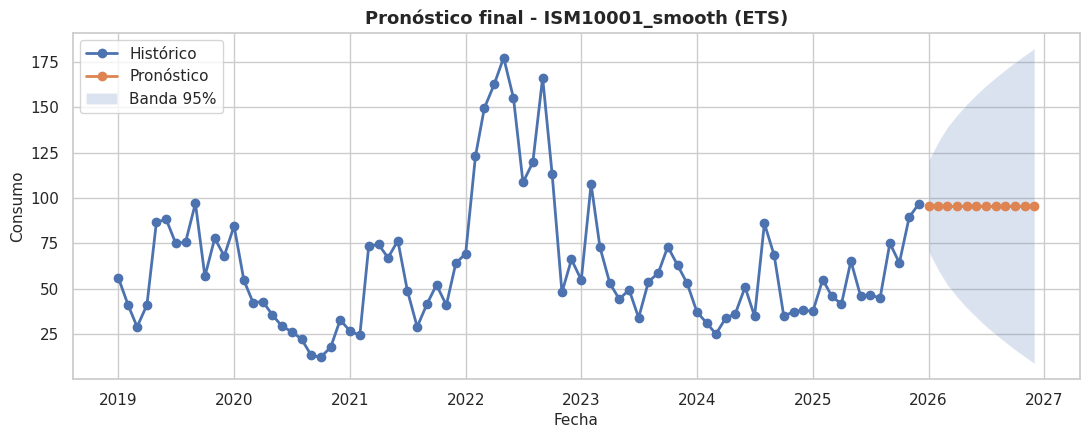

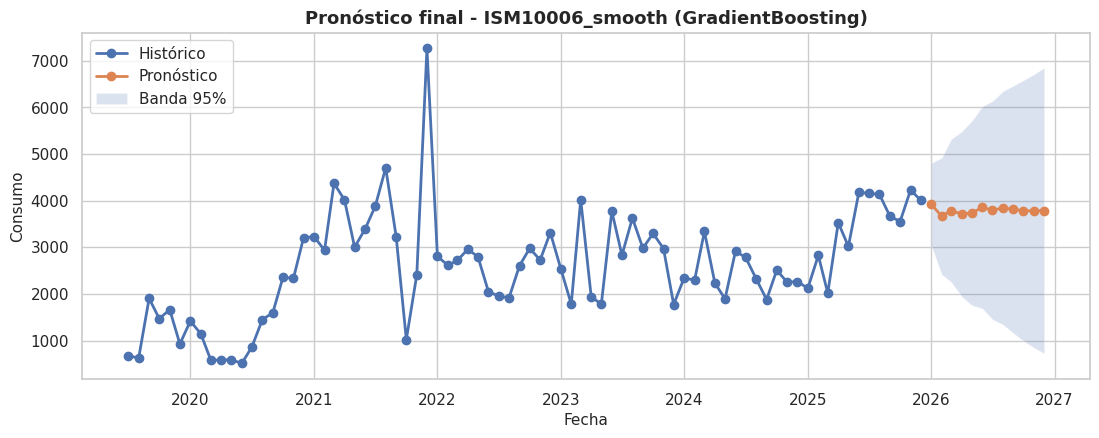

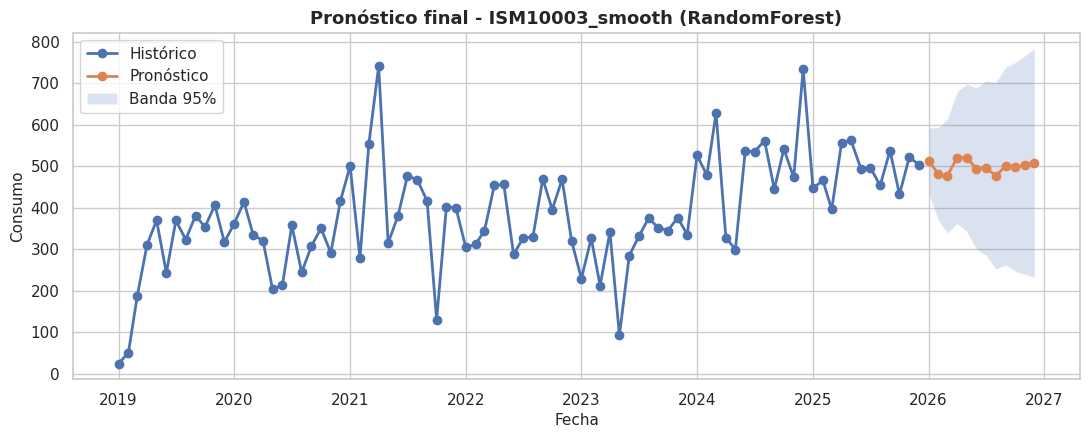

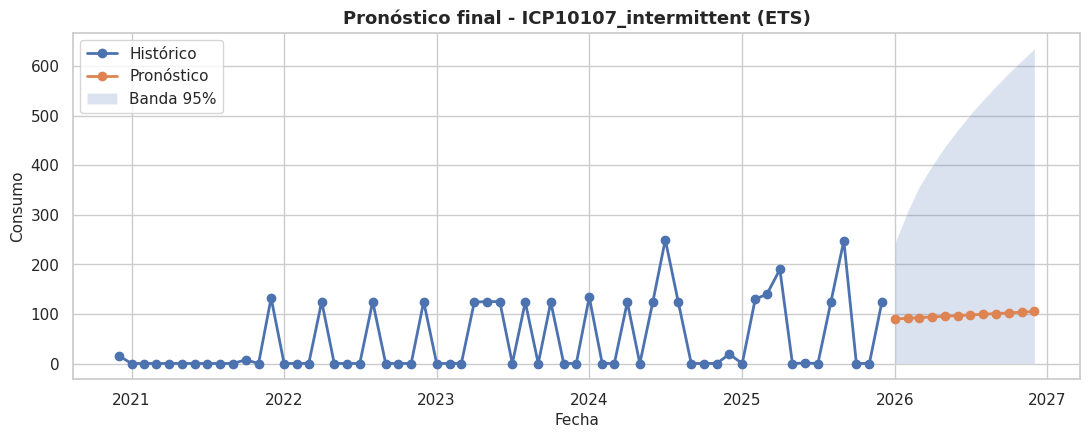

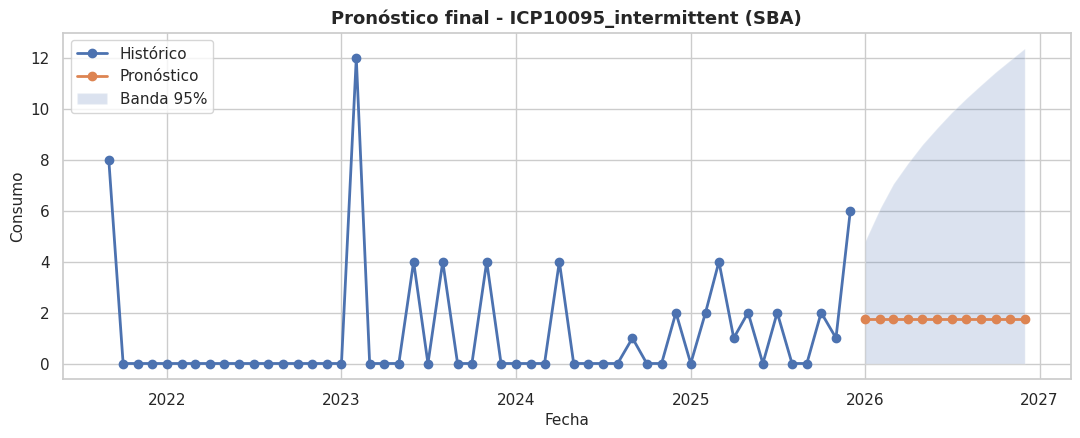

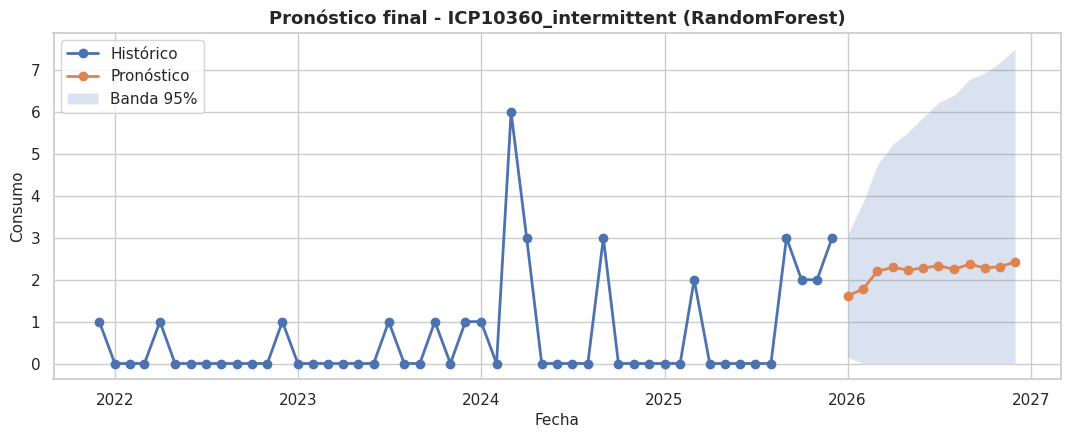

Archivo exportado en: /content/salidas_modelado_inventarios.xlsx


In [ ]:
# Proyecto 12 meses hacia adelante, diagnostico residuos y traduzco resultados a inventarios.
future_exog = build_future_exog(df, FORECAST_HORIZON)
z_value = norm.ppf(SERVICE_LEVEL)

forecast_rows = []
residual_diag_rows = []
inventory_rows = []

for _, row in best_model_per_series.iterrows():
    target = row["serie"]
    model_name = row["modelo"]
    df_series = get_active_frame(df, target)

    bt = backtest_store[(target, model_name)]
    residuals_bt = bt["actuals"] - bt["preds"]
    sigma_bt = float(np.std(residuals_bt, ddof=1)) if len(bt["actuals"]) > 1 else 0.0

    # Refito el mejor modelo sobre toda la historia y genero pronóstico futuro.
    if model_name in ("Naive", "SeasonalNaive"):
        preds = forecast_benchmark(df_series, target, model_name, FORECAST_HORIZON)

    elif model_name == "ETS":
        spec = model_registry_store[target][model_name]["spec"]
        fit = fit_ets(df_series[target], spec)
        preds = np.asarray(fit.forecast(FORECAST_HORIZON))

    elif model_name in ("ARIMA", "SARIMA"):
        spec = model_registry_store[target][model_name]["spec"]
        fit = fit_sarimax(df_series[target], spec)
        preds = np.asarray(fit.get_forecast(steps=FORECAST_HORIZON).predicted_mean)

    elif model_name == "SARIMAX":
        spec = model_registry_store[target][model_name]["spec"]
        fit = fit_sarimax(df_series[target], spec, exog_train=df_series[EXOG_COLS])
        preds = np.asarray(
            fit.get_forecast(
                steps=FORECAST_HORIZON,
                exog=future_exog[EXOG_COLS]
            ).predicted_mean
        )

    elif model_name in ("Croston", "SBA", "TSB"):
        spec = model_registry_store[target][model_name]["spec"]
        preds = croston_forecast(
            df_series[target].values,
            horizon=FORECAST_HORIZON,
            alpha=spec["alpha"],
            variant=spec["variant"]
        )

    else:
        preds = recursive_ml_forecast(
            df_series=df_series,
            target_col=target,
            model_name=model_name,
            model=ml_models[model_name],
            future_exog=future_exog,
            horizon=FORECAST_HORIZON
        )

    preds = np.maximum(preds, 0.0)

    for h, pred in enumerate(preds, start=1):
        band = z_value * sigma_bt * np.sqrt(h)
        forecast_rows.append({
            "serie": target,
            "fecha": future_exog.iloc[h - 1][DATE_COL],
            "modelo_ganador": model_name,
            "pronostico": float(pred),
            "li_95": float(max(0.0, pred - band)),
            "ls_95": float(pred + band),
        })

    # Diagnostico residuos a partir del backtesting, que es la validación relevante.
    residual_diag_rows.append({
        "serie": target,
        "modelo_ganador": model_name,
        **residual_diagnostics(residuals_bt)
    })

    # Calculo stock de seguridad y punto de reorden con un lead time mensual base.
    forecast_target = pd.DataFrame([r for r in forecast_rows if r["serie"] == target]).sort_values("fecha").reset_index(drop=True)
    demand_lt = float(forecast_target["pronostico"].head(LEAD_TIME_MONTHS).sum())
    safety_stock = float(z_value * sigma_bt * np.sqrt(LEAD_TIME_MONTHS))
    reorder_point = float(demand_lt + safety_stock)

    inventory_rows.append({
        "serie": target,
        "categoria_demanda": audit_lookup[target]["categoria"],
        "modelo_ganador": model_name,
        "service_level": SERVICE_LEVEL,
        "lead_time_meses": LEAD_TIME_MONTHS,
        "sigma_backtest": sigma_bt,
        "demanda_pronosticada_LT": demand_lt,
        "stock_seguridad": safety_stock,
        "punto_reorden": reorder_point,
    })

forecast_df = pd.DataFrame(forecast_rows)
residual_diag_df = pd.DataFrame(residual_diag_rows)
inventory_df = pd.DataFrame(inventory_rows)

display(Markdown("### Pronóstico futuro"))
display(
    forecast_df.style.format({
        "pronostico": "{:,.2f}",
        "li_95": "{:,.2f}",
        "ls_95": "{:,.2f}",
    })
)

display(Markdown("### Diagnóstico residual del modelo ganador"))
display(
    residual_diag_df.style.format({
        "ljung_box_pvalue": "{:.4f}",
        "jarque_bera_pvalue": "{:.4f}",
        "arch_lm_pvalue": "{:.4f}",
    })
)

display(Markdown("### Parámetros de inventario derivados del pronóstico"))
display(
    inventory_df.style.format({
        "service_level": "{:.0%}",
        "sigma_backtest": "{:,.2f}",
        "demanda_pronosticada_LT": "{:,.2f}",
        "stock_seguridad": "{:,.2f}",
        "punto_reorden": "{:,.2f}",
    })
)

# Grafico el pronóstico final por serie con bandas de incertidumbre.
for target in TARGET_COLS:
    hist = get_active_frame(df, target)[[DATE_COL, target]].copy()
    fc = forecast_df[forecast_df["serie"] == target].copy().sort_values("fecha")

    fig, ax = plt.subplots(figsize=(13, 4.5))
    ax.plot(hist[DATE_COL], hist[target], marker="o", linewidth=2, label="Histórico")
    ax.plot(fc["fecha"], fc["pronostico"], marker="o", linewidth=2, label="Pronóstico")
    ax.fill_between(fc["fecha"], fc["li_95"], fc["ls_95"], alpha=0.2, label="Banda 95%")
    ax.set_title(f"Pronóstico final - {target} ({fc['modelo_ganador'].iloc[0]})")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Consumo")
    ax.legend()
    plt.show()

# Exporto salidas para soporte del reporte.
output_path = Path("salidas_modelado_inventarios.xlsx")

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    audit_df.to_excel(writer, sheet_name="auditoria", index=False)
    diagnostic_df.to_excel(writer, sheet_name="diagnostico_econometrico", index=False)
    lag_corr_summary.to_excel(writer, sheet_name="correlaciones_lag", index=False)
    results_df.to_excel(writer, sheet_name="resultados_modelos", index=False)
    family_summary.to_excel(writer, sheet_name="resumen_familias", index=False)
    best_model_per_series.to_excel(writer, sheet_name="mejor_modelo_serie", index=False)
    forecast_df.to_excel(writer, sheet_name="pronosticos_12m", index=False)
    residual_diag_df.to_excel(writer, sheet_name="residuos", index=False)
    inventory_df.to_excel(writer, sheet_name="inventarios", index=False)

print(f"Archivo exportado en: {output_path.resolve()}")

# **Observaciones de interpretación**

- Un **p-value alto en Ljung-Box** es deseable porque sugiere residuos cercanos a ruido blanco.
- Un **p-value bajo en Jarque-Bera** no invalida por sí mismo el pronóstico; la prioridad es ausencia de autocorrelación remanente y estabilidad razonable del error.
- La tabla de inventarios utiliza un **lead time base de 1 mes**. Si luego se dispone de lead time por SKU, basta con reemplazar `LEAD_TIME_MONTHS` o ampliar esa parte con un diccionario por insumo.
- Para series clasificadas como **intermitentes** o **irregulares**, que gane Croston / SBA / TSB es perfectamente defendible desde el punto de vista metodológico.
- Para el reporte escrito, la lectura recomendada es:
  1. auditoría y clasificación de demanda,
  2. diagnóstico econométrico,
  3. comparación por familia,
  4. selección final por serie,
  5. traducción del pronóstico a stock de seguridad y punto de reorden.